**Objective: Instruction-Tuning Dataset Generation for Explainable Medical LLMs**

The objective of this notebook is to transform the validated multimodal cohort from Notebook 03 into structured instruction-tuning datasets for Explainable Medical LLM development. The notebook converts clinical variables, outcome labels, radiology-derived text, and image-linkage metadata into task-aware instruction records suitable for supervised fine-tuning, evaluation, and explainability analysis.

This notebook does not train a model directly. Instead, it prepares reproducible instruction datasets and audit artifacts that define how clinical inputs, expected outputs, labels, metadata, evidence fields, and multimodal references should be represented before downstream modeling.

**Technical and Clinical Significance**  
This step creates the supervised instruction layer of the project. It supports both early ED prediction tasks, based on information available near patient presentation, and retrospective reasoning tasks, where richer clinical context can be used. This separation helps reduce leakage risk and makes the dataset more suitable for clinically meaningful evaluation.

Clinically, the generated instructions preserve important information such as triage features, clinical text, outcome labels, image references, negation cues, severity indicators, and provenance fields. These elements support models that can be evaluated not only by prediction performance, but also by reasoning quality, evidence alignment, and transparency.
 
**Expected Main Outputs**  
The main outputs of this notebook include:

`instruction_dataset_early_ed_04_all.jsonl`  
A task-aware instruction dataset focused on early ED information available near presentation.

`instruction_dataset_retrospective_04_all.jsonl`  
A retrospective instruction dataset that can use richer clinical context, including report-derived text and multimodal metadata.

`instruction_dataset.jsonl`  
A backward-compatible instruction dataset export for general downstream use.

`instruction_task_variants_manifest_04.json`  
A manifest describing exported instruction task variants, row counts, split files, and dataset structure.

Additional audit-first outputs are also generated for Llama3-Med conversation packaging, CLIP linkage, CPLLM concept enrichment, MedTVT-R1 schema readiness, PointDetectCount task contracts, xHAIM explanation evaluation, MedBLIP caption instruction preparation, and MedTok query-to-code mapping.

**Preliminary Setup: Library Import, Artifact Registry, and Shared Utilities**

This setup prepares the notebook environment before instruction-dataset generation begins. It imports the required libraries, applies consistent plotting settings, verifies hardware availability, defines shared output folders, and registers helper functions used across later instruction-packaging stages.

In [1]:
# Imported Libraries (categorized)

# ---------------------------------------------------------
# Standard Library
# ---------------------------------------------------------
import sys
import os

# Add project root to sys.path to resolve 'src' imports
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

# ---------------------------------------------------------
# Data Handling and Manipulation Libraries
# ---------------------------------------------------------
import re
import json
import hashlib
from pathlib import Path

# ---------------------------------------------------------
# Core Data and Visualization
# ---------------------------------------------------------
import math
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# ---------------------------------------------------------
# Project Utilities
# ---------------------------------------------------------
from src.utils.hardware_verification import verify_hardware

# Global Plot Style Configuration
mpl.rcParams.update({
    "font.family":      "DejaVu Sans",
    "axes.titlesize":   12.5,
    "axes.titleweight": "normal",
    "axes.labelsize":   11.5,
    "axes.labelweight": "normal",
    "xtick.labelsize":  11,
    "ytick.labelsize":  11,
    "legend.fontsize":  10,
    "figure.dpi":       100,
})

print("Libraries imported and academic plotting style successfully applied.")

# Global Device Configuration for PyTorch
device = verify_hardware()
print(f"Global Computation Device Set To: {device}")


Libraries imported and academic plotting style successfully applied.
⏳ Initializing hardware verification protocol...

🖥️ OS: Windows 11 | CPU: Intel64 Family 6 Model 151 Stepping 2, GenuineIntel | RAM: 31.7 GB

✅ GPU Accelerator detected successfully.
🎮 Hardware Device: NVIDIA GeForce RTX 3090
💾 Total VRAM Allocated: 24.00 GB
🚀 System is fully optimized and ready for heavy tensor operations.

🔧 PyTorch Version: 2.6.0+cu124
✅ PyTorch CUDA is available.
   Device Name : NVIDIA GeForce RTX 3090
   CUDA Version: 12.4
   cuDNN Version: 90100
   VRAM (PyTorch): 24.00 GB
   Selected Device: cuda
Global Computation Device Set To: cuda


In [2]:
# ===============================================================================
# Pipeline Infrastructure & Shared Utilities
# ===============================================================================

# ----------------------------------------------
# 0) Global Path Setup
# ----------------------------------------------
BASE_DIR = Path.home() / "OneDrive - hull.ac.uk" / "Explainable Medical LLM Dataset" / "datasets"
QUALITY_DIR = BASE_DIR / "quality_reports"
OUTPUTS_DIR = BASE_DIR / "outputs"
QUALITY_DIR.mkdir(parents=True, exist_ok=True)
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Base directory:   {BASE_DIR}")
print(f"Quality reports : {QUALITY_DIR}")
print(f"Outputs         : {OUTPUTS_DIR}")

# ----------------------------------------------
# 1) Instruction DataFrame Resolver
# ----------------------------------------------
def resolve_instruction_df(step_label: str = "") -> tuple:
    """
    Locate the active instruction DataFrame from memory or disk.
    Default downstream behavior uses the retrospective task variant to preserve
    compatibility with the original Notebook 04 -> 05 pipeline.
    Returns: (df, source_name)
    """
    priority_vars = [
        "df_instruction_retrospective",
        "df_instruction_set",
        "df_instruction_early",
        "df_instruction",
        "instruction_df",
        "df_cohort_supervised",
    ]

    for var_name in priority_vars:
        obj = globals().get(var_name)
        if isinstance(obj, pd.DataFrame) and len(obj) > 0:
            return obj.copy(), var_name

    if "dataset" in globals():
        try:
            candidate = pd.DataFrame(dataset)
            if len(candidate) > 0:
                return candidate, "dataset"
        except Exception:
            pass

    for p in [
        OUTPUTS_DIR / "instruction_dataset_retrospective_04_all.jsonl",
        OUTPUTS_DIR / "instruction_dataset_early_ed_04_all.jsonl",
        OUTPUTS_DIR / "instruction_dataset_pointdetect_ready_04.jsonl",
        OUTPUTS_DIR / "instruction_dataset_medtvt_ready_04.jsonl",
        OUTPUTS_DIR / "instruction_dataset_cpllm_augmented_04.jsonl",
        OUTPUTS_DIR / "instruction_dataset_clip_bridge_04.jsonl",
        OUTPUTS_DIR / "instruction_dataset_llama3med.json",
        OUTPUTS_DIR / "instruction_dataset.jsonl",
    ]:
        if p.exists():
            try:
                df = pd.read_json(p, lines=True) if str(p).endswith(".jsonl") else pd.read_json(p)
                if len(df) > 0:
                    return df, str(p)
            except Exception:
                continue

    raise RuntimeError(f"[{step_label}] No instruction dataframe found. Run Steps 1-3 first.")

# -----------------------------------------------
# 2) Column-Aware JSONL Supplementer
# -----------------------------------------------
def resolve_fallback_jsonl(
    df: pd.DataFrame,
    required_cols: list,
    step_label: str = "",
) -> tuple:
    """
    If df is missing ALL required_cols, attempt to load a richer JSONL artifact.
    """
    if any(c in df.columns for c in required_cols):
        return df, None

    candidates = [
        OUTPUTS_DIR / "medimg_instruction_pack_04.jsonl",
        OUTPUTS_DIR / "instruction_dataset_pointdetect_ready_04.jsonl",
        OUTPUTS_DIR / "instruction_dataset_retrospective_04_all.jsonl",
        OUTPUTS_DIR / "instruction_dataset.jsonl",
    ]

    for p in candidates:
        if not p.exists():
            continue
        try:
            rows = [json.loads(line) for line in p.read_text(encoding="utf-8").splitlines() if line.strip()]
            if rows:
                return pd.DataFrame(rows), str(p)
        except Exception:
            continue

    return df, None

# ----------------------------------------------
# 3) Audit Payload Saver
# ----------------------------------------------
def save_step_payload(payload: dict, path) -> None:
    """Unified JSON audit writer."""
    with open(path, "w", encoding="utf-8") as f:
        json.dump(payload, f, indent=2, ensure_ascii=False)

print("resolve_instruction_df() and save_step_payload() ready.")

# ----------------------------------------------
# 4) Unified Step Artifact Exporter
# ----------------------------------------------
def export_step_artifacts(
    export_df: pd.DataFrame,
    audit_df: pd.DataFrame,
    summary_payload: dict,
    prefix: str,
    *,
    preview_rows: int = 3000,
    jsonl_path: Path = None,
    json_format: bool = False,
) -> dict:
    """
    Persist standard step outputs:
    - audit CSV
    - preview CSV
    - JSONL/JSON export
    - payload JSON
    """
    audit_path = QUALITY_DIR / f"{prefix}_audit.csv"
    preview_path = QUALITY_DIR / f"{prefix}_preview.csv"
    export_path = jsonl_path or (
        OUTPUTS_DIR / f"{prefix}.json" if json_format else OUTPUTS_DIR / f"{prefix}.jsonl"
    )
    payload_path = QUALITY_DIR / f"{prefix}_payload.json"

    audit_df.to_csv(audit_path, index=False)
    audit_df.head(preview_rows).to_csv(preview_path, index=False)

    if json_format:
        with open(export_path, "w", encoding="utf-8") as f:
            json.dump(export_df.to_dict("records"), f, indent=2, ensure_ascii=False)
    else:
        export_df.to_json(export_path, orient="records", lines=True, force_ascii=False)

    save_step_payload(summary_payload, payload_path)

    return {
        "audit": audit_path,
        "preview": preview_path,
        "export": export_path,
        "payload": payload_path,
    }

# -----------------------------------------------------------------
# 5) Base Instruction Column Sanitiser
# -----------------------------------------------------------------
def ensure_base_instruction_columns(
    df: pd.DataFrame,
    cols: list = None,
) -> pd.DataFrame:
    """
    Guarantee instruction/input/output-style columns exist and are clean strings.
    """
    if cols is None:
        cols = ["instruction", "input", "output"]

    for c in cols:
        if c not in df.columns:
            df[c] = ""
        df[c] = df[c].fillna("").astype(str)

    return df

# -----------------------------------------------------------------
# 6) Deterministic Patient-Level Split Utilities
# -----------------------------------------------------------------
def stable_subject_split(subject_id, namespace: str = "instruction04", train_pct: int = 80, val_pct: int = 10) -> str:
    """
    Stable patient-level split using md5(subject_id). All rows from the same
    subject_id receive the same split across reruns.
    """
    key = f"{namespace}::{str(subject_id)}"
    bucket = int(hashlib.md5(key.encode("utf-8")).hexdigest()[:8], 16) % 100

    if bucket < train_pct:
        return "train"
    if bucket < train_pct + val_pct:
        return "val"
    return "test"


def build_patient_split_map(
    df: pd.DataFrame,
    subject_col: str = "subject_id",
    namespace: str = "instruction04",
) -> pd.DataFrame:
    """Build one split assignment per unique patient."""
    if subject_col not in df.columns:
        raise KeyError(f"Patient-level split requires '{subject_col}'.")

    subjects = (
        df[subject_col]
        .dropna()
        .astype(str)
        .drop_duplicates()
        .sort_values()
        .tolist()
    )

    split_map = pd.DataFrame({subject_col: subjects})
    split_map["split"] = split_map[subject_col].map(
        lambda x: stable_subject_split(x, namespace=namespace)
    )
    return split_map


def audit_patient_split(
    df: pd.DataFrame,
    split_col: str = "split",
    subject_col: str = "subject_id",
    label_col: str = "label_mortality_observed",
) -> pd.DataFrame:
    """Create split-level row, patient, and label distribution audit."""
    required = [split_col, subject_col]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise KeyError(f"Missing split audit columns: {missing}")

    rows = []
    for split_name, part in df.groupby(split_col, dropna=False):
        item = {
            "split": split_name,
            "rows": int(len(part)),
            "unique_subjects": int(part[subject_col].nunique()),
        }

        if label_col in part.columns:
            y = pd.to_numeric(part[label_col], errors="coerce")
            observed = y.dropna()
            item["expired_rows"] = int((observed == 1).sum())
            item["survived_rows"] = int((observed == 0).sum())
            item["mortality_rate_pct"] = round(float((observed == 1).mean() * 100.0), 4) if len(observed) else 0.0

        rows.append(item)

    audit_df = pd.DataFrame(rows).sort_values("split").reset_index(drop=True)

    subject_split_counts = df.groupby(subject_col)[split_col].nunique()
    leaking_subjects = subject_split_counts[subject_split_counts > 1]

    audit_df["subjects_in_multiple_splits"] = int(len(leaking_subjects))
    return audit_df

# --------------------------------------------------
# 7) Cross-Notebook Artifact Registry
# --------------------------------------------------
ARTIFACTS = {
    # Notebook 02 outputs
    "cpllm_term_bank_csv": QUALITY_DIR / "cpllm_text_term_bank_02.csv",
    "cpllm_term_bank_json": OUTPUTS_DIR / "cpllm_term_bank_02.json",

    # Notebook 03 outputs
    "clip_index_primary": OUTPUTS_DIR / "clip_image_embeddings_index_03.csv",
    "clip_index_fallback": OUTPUTS_DIR / "clip_image_embeddings_index.csv",
    "medblip_seed_index": OUTPUTS_DIR / "medimg_caption_seed_index_03.csv",

    # Notebook 04 task-aware outputs
    "instruction_split_map": QUALITY_DIR / "instruction_patient_split_map_04.csv",
    "instruction_split_audit": QUALITY_DIR / "instruction_patient_split_audit_04.csv",
    "instruction_manifest": QUALITY_DIR / "instruction_task_variants_manifest_04.json",
}

print("Cross-notebook artifact registry loaded.")
print(f"  Registered artifacts: {len(ARTIFACTS)}")


Base directory:   C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets
Quality reports : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports
Outputs         : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\outputs
resolve_instruction_df() and save_step_payload() ready.
Cross-notebook artifact registry loaded.
  Registered artifacts: 8


**Step 1: Master Cohort Loading, Outcome Validation, and Patient-Level Splitting**

This step loads the multimodal master cohort generated in Notebook 03 and prepares it for supervised instruction generation. It validates the required clinical features, resolves the mortality outcome label, removes rows with missing essential inputs, and creates a deterministic patient-level train, validation, and test split.

**Main Operations**  
◽ Load `multimodal_master_cohort.csv` from the shared outputs directory  
◽ Select required clinical features, label columns, and available metadata fields  
◽ Validate core ED variables such as age, gender, acuity, vital signs, and chief complaint  
◽ Resolve the mortality outcome using governed labels or `hospital_expire_flag` fallback  
◽ Remove rows with missing required input features  
◽ Exclude rows with unknown outcome labels from supervised instruction generation  
◽ Assign patient-level train, validation, and test splits using stable hashing  
◽ Export split maps and split-leakage audit files  

**Technical and Clinical Significance**  
This step defines the supervised population used for instruction tuning. Patient-level splitting is essential because multiple records from the same patient must not appear across different evaluation partitions. This protects downstream model evaluation from patient-level leakage.

**Expected Outcome**  
A cleaned supervised cohort, `df_cohort_supervised`, is available with validated clinical inputs, observed mortality labels, clinical-text availability flags, and deterministic patient-level split assignments.

In [3]:
# Step 1: Environment configuration and ingestion of the master multimodal cohort

print("Initializing base directory for local Windows environment...")

if "BASE_DIR" not in globals():
    raise RuntimeError("Run Helper Cell first - BASE_DIR not defined.")

PATH_MASTER_COHORT = OUTPUTS_DIR / "multimodal_master_cohort.csv"

if not PATH_MASTER_COHORT.exists():
    raise FileNotFoundError(
        f"The file {PATH_MASTER_COHORT.name} is missing. Ensure upstream notebooks completed successfully."
    )

print("\nLoading multimodal master cohort...")

# Inspect header first so column selection is robust across upstream schema variants.
available_columns = pd.read_csv(PATH_MASTER_COHORT, nrows=0).columns.tolist()

required_feature_columns = [
    "subject_id",
    "stay_id",
    "temperature",
    "heartrate",
    "sbp",
]

recommended_feature_columns = [
    "resprate",
    "o2sat",
    "dbp",
    "chiefcomplaint",
    "clinical_text",
]

optional_metadata_columns = [
    "hadm_id",
    "study_id",
    "dicom_id",
    "intime",
    "outtime",
    "cxr_datetime",
    "StudyDate",
    "StudyTime",
    "ViewPosition",
    "expected_image_path",
    "image_path",
    "cohort_strategy",
]

missing_required_features = [c for c in required_feature_columns if c not in available_columns]
if missing_required_features:
    raise KeyError(f"Missing required feature columns in master cohort: {missing_required_features}")

present_recommended_columns = [c for c in recommended_feature_columns if c in available_columns]
present_optional_columns = [c for c in optional_metadata_columns if c in available_columns]

has_label_observed = "label_mortality_observed" in available_columns
has_label_missing = "label_outcome_missing" in available_columns
has_hospital_flag = "hospital_expire_flag" in available_columns

if has_label_observed and has_label_missing:
    label_columns = ["label_mortality_observed", "label_outcome_missing"]
    label_source = "governed_labels"
elif has_hospital_flag:
    label_columns = ["hospital_expire_flag"]
    label_source = "hospital_expire_flag_fallback"
else:
    raise KeyError(
        "No usable outcome label source found. Expected governed labels or hospital_expire_flag."
    )

use_columns = (
    required_feature_columns
    + present_recommended_columns
    + present_optional_columns
    + label_columns
)
use_columns = list(dict.fromkeys(use_columns))

df_cohort = pd.read_csv(PATH_MASTER_COHORT, usecols=use_columns)

print(f"Loaded rows: {len(df_cohort):,}")
print(f"Label source: {label_source}")
print(f"Required columns loaded: {required_feature_columns}")
print(f"Recommended columns loaded: {present_recommended_columns}")
print(f"Optional metadata columns loaded: {present_optional_columns}")

# Feature-quality filtering before instruction construction.
# Important: clinical_text is NOT required here, because the early ED task must not depend on radiology text.
rows_before_feature_qc = int(len(df_cohort))
df_cohort = df_cohort.dropna(subset=required_feature_columns).copy()
rows_after_feature_qc = int(len(df_cohort))

print(f"Rows before feature quality filtering: {rows_before_feature_qc:,}")
print(f"Rows after feature quality filtering : {rows_after_feature_qc:,}")

# Ensure optional text columns exist for downstream prompt construction.
if "chiefcomplaint" not in df_cohort.columns:
    df_cohort["chiefcomplaint"] = "Not recorded"

if "clinical_text" not in df_cohort.columns:
    df_cohort["clinical_text"] = ""

df_cohort["clinical_text"] = df_cohort["clinical_text"].fillna("").astype(str)
df_cohort["has_clinical_text"] = df_cohort["clinical_text"].str.strip().str.len().gt(0).astype("int8")

# Canonical label governance fields.
if label_source == "governed_labels":
    df_cohort["label_mortality_observed"] = pd.to_numeric(
        df_cohort["label_mortality_observed"], errors="coerce"
    )
    df_cohort["label_outcome_missing"] = pd.to_numeric(
        df_cohort["label_outcome_missing"], errors="coerce"
    ).fillna(df_cohort["label_mortality_observed"].isna().astype("int8")).astype("int8")
else:
    df_cohort["hospital_expire_flag"] = pd.to_numeric(
        df_cohort["hospital_expire_flag"], errors="coerce"
    )
    df_cohort["label_outcome_missing"] = df_cohort["hospital_expire_flag"].isna().astype("int8")
    df_cohort["label_mortality_observed"] = df_cohort["hospital_expire_flag"]

# Supervised gate: keep only observed outcomes for model-training data.
rows_before_gate = int(len(df_cohort))
df_cohort_supervised = df_cohort[df_cohort["label_outcome_missing"] == 0].copy()
rows_after_gate = int(len(df_cohort_supervised))
rows_excluded_unknown = rows_before_gate - rows_after_gate

if rows_after_gate == 0:
    raise RuntimeError("No observed outcomes remain after supervised label gate.")

# Patient-level split assignment.
split_map = build_patient_split_map(
    df_cohort_supervised,
    subject_col="subject_id",
    namespace="instruction04_patient_split",
)

df_cohort_supervised["subject_id"] = df_cohort_supervised["subject_id"].astype(str)
split_map["subject_id"] = split_map["subject_id"].astype(str)

df_cohort_supervised = df_cohort_supervised.merge(
    split_map,
    on="subject_id",
    how="left",
)

if df_cohort_supervised["split"].isna().any():
    raise RuntimeError("Some supervised rows did not receive a patient-level split assignment.")

split_audit_df = audit_patient_split(
    df_cohort_supervised,
    split_col="split",
    subject_col="subject_id",
    label_col="label_mortality_observed",
)

subject_overlap_count = int(split_audit_df["subjects_in_multiple_splits"].max())
if subject_overlap_count > 0:
    raise RuntimeError(f"Patient-level split leakage detected: {subject_overlap_count} subjects overlap splits.")

# Persist split governance artifacts.
split_map_path = QUALITY_DIR / "instruction_patient_split_map_04.csv"
split_audit_path = QUALITY_DIR / "instruction_patient_split_audit_04.csv"

split_map.to_csv(split_map_path, index=False)
split_audit_df.to_csv(split_audit_path, index=False)

print(f"Rows before supervised gate: {rows_before_gate:,}")
print(f"Rows after supervised gate : {rows_after_gate:,}")
print(f"Rows excluded (unknown outcome): {rows_excluded_unknown:,}")
print(f"Rows with clinical_text: {int(df_cohort_supervised['has_clinical_text'].sum()):,}")
print(f"Patient-level split map saved: {split_map_path}")
print(f"Patient-level split audit saved: {split_audit_path}")

display(split_audit_df)


Initializing base directory for local Windows environment...

Loading multimodal master cohort...
Loaded rows: 88,570
Label source: governed_labels
Required columns loaded: ['subject_id', 'stay_id', 'temperature', 'heartrate', 'sbp']
Recommended columns loaded: ['resprate', 'o2sat', 'dbp', 'chiefcomplaint', 'clinical_text']
Optional metadata columns loaded: ['hadm_id', 'study_id', 'dicom_id', 'intime', 'outtime', 'cxr_datetime', 'StudyDate', 'StudyTime', 'ViewPosition', 'expected_image_path', 'image_path', 'cohort_strategy']
Rows before feature quality filtering: 88,570
Rows after feature quality filtering : 80,386
Rows before supervised gate: 80,386
Rows after supervised gate : 55,891
Rows excluded (unknown outcome): 24,495
Rows with clinical_text: 55,891
Patient-level split map saved: C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\instruction_patient_split_map_04.csv
Patient-level split audit saved: C:\Users\927997\OneDrive - hull.ac.uk

,split,rows,unique_subjects,expired_rows,survived_rows,mortality_rate_pct,subjects_in_multiple_splits
0,test,5368,3233,126,5242,2.3472,0
1,train,44910,27014,1014,43896,2.2578,0
2,val,5613,3407,143,5470,2.5477,0


**Step 2: Task-Aware Clinical Prompt Engineering and Instruction Formatting**

This step converts supervised cohort rows into structured instruction records. Two task variants are created: an early ED prediction task using information available near presentation, and a retrospective multimodal task that can also include linked radiology-derived clinical text.

**Main Operations**  
◽ Prepare default values for missing optional clinical fields  
◽ Convert observed mortality labels into supervised text outputs  
◽ Build early ED inputs from chief complaint, demographics, acuity, and triage vital signs  
◽ Build retrospective inputs by extending early ED information with radiology-derived clinical text  
◽ Create `df_instruction_early` for early ED mortality prediction  
◽ Create `df_instruction_retrospective` for richer multimodal mortality reasoning  
◽ Preserve metadata fields such as patient IDs, study IDs, image references, split labels, and text-usage flags  
◽ Display sample prompts for both task variants  

**Technical and Clinical Significance**  
Separating early ED and retrospective tasks makes the dataset more clinically meaningful. The early ED version supports leakage-safer prediction based on information available at presentation, while the retrospective version supports richer reasoning and multimodal ablation studies.

**Expected Outcome**  
Two task-aware instruction dataframes are created: `df_instruction_early` and `df_instruction_retrospective`, with standardized `instruction`, `input`, `output`, metadata, and task-variant fields.

In [4]:
# Step 2: Transformation of observed-outcome clinical records into task-aware instruction prompts

print("Initiating task-aware clinical prompt engineering pipeline...")

# -----------------------------------------------------------------
# 0) Guard: upstream dependency
# -----------------------------------------------------------------
if "df_cohort_supervised" not in globals():
    raise RuntimeError("df_cohort_supervised not found. Run Step 1 first.")

required_cols = [
    "subject_id",
    "stay_id",
    "temperature",
    "heartrate",
    "sbp",
    "label_mortality_observed",
    "split",
]
missing_required = [c for c in required_cols if c not in df_cohort_supervised.columns]
if missing_required:
    raise KeyError(f"df_cohort_supervised is missing required columns: {missing_required}")

# -----------------------------------------------------------------
# 1) Working copy and safe defaults
# -----------------------------------------------------------------
df_work = df_cohort_supervised.copy()

# Optional columns are normalized so prompt construction is robust.
optional_defaults = {
    "chiefcomplaint": "Not recorded",
    "resprate": "Not recorded",
    "o2sat": "Not recorded",
    "dbp": "Not recorded",
    "clinical_text": "",
}

for col, default_value in optional_defaults.items():
    if col not in df_work.columns:
        df_work[col] = default_value
    df_work[col] = df_work[col].fillna(default_value)

df_work["clinical_text"] = df_work["clinical_text"].fillna("").astype(str)
df_work["has_clinical_text"] = df_work["clinical_text"].str.strip().str.len().gt(0).astype("int8")

# -----------------------------------------------------------------
# 2) Shared output column
# -----------------------------------------------------------------
_output_map = {
    1: "Outcome: EXPIRED.",
    1.0: "Outcome: EXPIRED.",
    0: "Outcome: SURVIVED.",
    0.0: "Outcome: SURVIVED.",
}

df_work["output"] = df_work["label_mortality_observed"].map(_output_map)

if df_work["output"].isna().any():
    bad_values = sorted(df_work.loc[df_work["output"].isna(), "label_mortality_observed"].dropna().unique().tolist())
    raise ValueError(f"Encountered unknown outcome values in supervised dataset: {bad_values}")

# -----------------------------------------------------------------
# 3) Shared ED triage input block
# -----------------------------------------------------------------
df_work["input_early_ed"] = (
    "Chief Complaint: "
    + df_work["chiefcomplaint"].astype(str).replace("", "Not recorded")
    + "\n"
    + "Triage Vitals - Temperature: "
    + df_work["temperature"].astype(str)
    + " F, "
    + "Heart Rate: "
    + df_work["heartrate"].astype(str)
    + " bpm, "
    + "Respiratory Rate: "
    + df_work["resprate"].astype(str)
    + " bpm, "
    + "O2 Saturation: "
    + df_work["o2sat"].astype(str)
    + "%, "
    + "Blood Pressure: "
    + df_work["sbp"].astype(str)
    + "/"
    + df_work["dbp"].astype(str)
    + " mmHg"
)

df_work["input_retrospective"] = (
    df_work["input_early_ed"]
    + "\n"
    + "Radiology Report: "
    + df_work["clinical_text"].where(
        df_work["clinical_text"].str.strip().str.len() > 0,
        "No radiology text available.",
    )
)

# -----------------------------------------------------------------
# 4) Task-specific instructions
# -----------------------------------------------------------------
INSTRUCTION_EARLY_ED = (
    "Analyze the emergency department triage data available at presentation. "
    "Predict whether the patient survived or expired during the hospital stay."
)

INSTRUCTION_RETROSPECTIVE = (
    "Analyze the emergency department triage data and linked radiology report. "
    "Predict whether the patient survived or expired during the hospital stay."
)

# -----------------------------------------------------------------
# 5) Metadata columns to preserve for split, audit, and downstream linkage
# -----------------------------------------------------------------
metadata_cols = [
    "subject_id",
    "stay_id",
    "hadm_id",
    "study_id",
    "dicom_id",
    "split",
    "label_mortality_observed",
    "label_outcome_missing",
    "has_clinical_text",
    "cxr_datetime",
    "intime",
    "outtime",
    "expected_image_path",
    "image_path",
    "ViewPosition",
    "cohort_strategy",
]
metadata_cols = [c for c in metadata_cols if c in df_work.columns]

# -----------------------------------------------------------------
# 6) Build early ED instruction dataset
# -----------------------------------------------------------------
df_instruction_early = df_work[metadata_cols].copy()
df_instruction_early["task_variant"] = "early_ed_mortality"
df_instruction_early["instruction"] = INSTRUCTION_EARLY_ED
df_instruction_early["input"] = df_work["input_early_ed"]
df_instruction_early["output"] = df_work["output"]
df_instruction_early["uses_clinical_text"] = 0

# -----------------------------------------------------------------
# 7) Build retrospective multimodal instruction dataset
# -----------------------------------------------------------------
df_instruction_retrospective = df_work[metadata_cols].copy()
df_instruction_retrospective["task_variant"] = "retrospective_multimodal_mortality"
df_instruction_retrospective["instruction"] = INSTRUCTION_RETROSPECTIVE
df_instruction_retrospective["input"] = df_work["input_retrospective"]
df_instruction_retrospective["output"] = df_work["output"]
df_instruction_retrospective["uses_clinical_text"] = 1

# Backward-compatible aliases for existing downstream cells.
# Existing Notebook 04/05 behavior used triage + radiology text, so the legacy alias remains retrospective.
df_instruction_set = df_instruction_retrospective.copy()

df_cohort_supervised = df_work.copy()
df_cohort_supervised["instruction"] = df_instruction_retrospective["instruction"]
df_cohort_supervised["input"] = df_instruction_retrospective["input"]
df_cohort_supervised["output"] = df_instruction_retrospective["output"]
df_cohort_supervised["task_variant"] = "retrospective_multimodal_mortality"
df_cohort_supervised["uses_clinical_text"] = 1

# -----------------------------------------------------------------
# 8) Summary + sample preview
# -----------------------------------------------------------------
print("\nPrompt engineering completed.")
print(f"Early ED instruction samples          : {len(df_instruction_early):,}")
print(f"Retrospective instruction samples     : {len(df_instruction_retrospective):,}")
print(f"Rows with radiology clinical_text     : {int(df_work['has_clinical_text'].sum()):,}")
print("Legacy df_instruction_set variant     : retrospective_multimodal_mortality")

split_summary = (
    df_instruction_retrospective
    .groupby(["task_variant", "split"], dropna=False)
    .size()
    .reset_index(name="rows")
)
display(split_summary)

sample_idx = 0

print("\n--- Sample Early ED Prompt ---")
print(f"INSTRUCTION:\n{df_instruction_early['instruction'].iloc[sample_idx]}\n")
print(f"INPUT:\n{df_instruction_early['input'].iloc[sample_idx]}\n")
print(f"OUTPUT:\n{df_instruction_early['output'].iloc[sample_idx]}")

print("\n--- Sample Retrospective Prompt ---")
print(f"INSTRUCTION:\n{df_instruction_retrospective['instruction'].iloc[sample_idx]}\n")
print(f"INPUT:\n{df_instruction_retrospective['input'].iloc[sample_idx]}\n")
print(f"OUTPUT:\n{df_instruction_retrospective['output'].iloc[sample_idx]}")


Initiating task-aware clinical prompt engineering pipeline...

Prompt engineering completed.
Early ED instruction samples          : 55,891
Retrospective instruction samples     : 55,891
Rows with radiology clinical_text     : 55,891
Legacy df_instruction_set variant     : retrospective_multimodal_mortality


,task_variant,split,rows
0,retrospective_multimodal_mortality,test,5368
1,retrospective_multimodal_mortality,train,44910
2,retrospective_multimodal_mortality,val,5613



--- Sample Early ED Prompt ---
INSTRUCTION:
Analyze the emergency department triage data available at presentation. Predict whether the patient survived or expired during the hospital stay.

INPUT:
Chief Complaint: Hypotension
Triage Vitals - Temperature: 97.8 F, Heart Rate: 87.0 bpm, Respiratory Rate: 14.0 bpm, O2 Saturation: 97.0%, Blood Pressure: 71.0/43.0 mmHg

OUTPUT:
Outcome: SURVIVED.

--- Sample Retrospective Prompt ---
INSTRUCTION:
Analyze the emergency department triage data and linked radiology report. Predict whether the patient survived or expired during the hospital stay.

INPUT:
Chief Complaint: Hypotension
Triage Vitals - Temperature: 97.8 F, Heart Rate: 87.0 bpm, Respiratory Rate: 14.0 bpm, O2 Saturation: 97.0%, Blood Pressure: 71.0/43.0 mmHg
Radiology Report: FINDINGS: Single frontal view of the chest provided. There is no focal consolidation, effusion, or pneumothorax. The cardiomediastinal silhouette is normal. Again seen are multiple clips projecting over the left

**Step 3.1: Instruction Dataset Export and Task Manifest Generation**

This step exports the generated instruction datasets to JSONL format. Both early ED and retrospective task variants are saved as complete datasets and as split-specific train, validation, and test files. A backward-compatible legacy instruction file is also preserved for later notebooks.

**Main Operations**  
◽ Validate that both instruction variants contain the required `instruction`, `input`, and `output` columns  
◽ Export early ED and retrospective instruction datasets as JSONL files  
◽ Save split-specific train, validation, and test files for each task variant  
◽ Export the retrospective test split as a strict evaluation holdout  
◽ Save a backward-compatible `instruction_dataset.jsonl` file  
◽ Generate label-distribution and split-audit summaries  
◽ Save a task manifest describing exported variants, row counts, split counts, labels, and file paths  

**Technical and Clinical Significance**  
JSONL export makes the dataset compatible with common instruction-tuning pipelines. The task manifest provides a reproducible record of what was exported, which task each file represents, and how the data is split for training and evaluation.

**Expected Outcome**  
Task-aware JSONL instruction datasets, split-specific files, an evaluation holdout file, and manifest/audit artifacts are saved for downstream model development.

In [5]:
# Step 3.1: Export Task-Aware Instruction-Tuning Datasets to JSONL

print("Initiating export of task-aware instruction-tuning datasets...")

# -----------------------------------------------------------------
# 0) Guard: upstream steps must have run
# -----------------------------------------------------------------
required_frames = ["df_instruction_early", "df_instruction_retrospective", "df_cohort_supervised"]
missing_frames = [x for x in required_frames if x not in globals()]
if missing_frames:
    raise RuntimeError(f"Missing required dataframes from Step 2: {missing_frames}")

required_instruction_cols = {"instruction", "input", "output", "split"}
for frame_name in ["df_instruction_early", "df_instruction_retrospective"]:
    frame = globals()[frame_name]
    missing_cols = required_instruction_cols - set(frame.columns)
    if missing_cols:
        raise RuntimeError(f"{frame_name} is missing required columns: {sorted(missing_cols)}")

# -----------------------------------------------------------------
# 1) Export configuration
# -----------------------------------------------------------------
TASK_EXPORTS = {
    "early_ed": {
        "df": df_instruction_early.copy(),
        "variant_name": "early_ed_mortality",
        "prefix": "instruction_dataset_early_ed_04",
        "uses_clinical_text": False,
        "description": "Early ED mortality prediction using chief complaint and triage vitals only.",
    },
    "retrospective": {
        "df": df_instruction_retrospective.copy(),
        "variant_name": "retrospective_multimodal_mortality",
        "prefix": "instruction_dataset_retrospective_04",
        "uses_clinical_text": True,
        "description": "Retrospective multimodal mortality classification using ED triage data and linked radiology text.",
    },
}

core_training_cols = ["instruction", "input", "output"]

metadata_cols = [
    "task_variant",
    "subject_id",
    "stay_id",
    "hadm_id",
    "study_id",
    "dicom_id",
    "split",
    "label_mortality_observed",
    "label_outcome_missing",
    "has_clinical_text",
    "uses_clinical_text",
    "cxr_datetime",
    "intime",
    "outtime",
    "expected_image_path",
    "image_path",
    "ViewPosition",
    "cohort_strategy",
]

# Keep metadata where available for audit/future notebooks, while preserving instruction fields.
def _ordered_export_columns(df: pd.DataFrame) -> list:
    return core_training_cols + [c for c in metadata_cols if c in df.columns and c not in core_training_cols]


def _write_jsonl(df: pd.DataFrame, path: Path, cols: list = None) -> None:
    export_df = df[cols].copy() if cols is not None else df.copy()
    export_df.to_json(path, orient="records", lines=True, force_ascii=False)


def _split_counts(df: pd.DataFrame) -> dict:
    return {
        split_name: int(count)
        for split_name, count in df["split"].value_counts(dropna=False).sort_index().items()
    }


def _label_counts(df: pd.DataFrame) -> dict:
    y = df["output"].fillna("").astype(str).str.upper()
    return {
        "EXPIRED": int(y.str.contains(r"\bEXPIRED\b", regex=True).sum()),
        "SURVIVED": int(y.str.contains(r"\bSURVIVED\b", regex=True).sum()),
    }


def _split_label_audit(df: pd.DataFrame, task_name: str) -> pd.DataFrame:
    rows = []
    for split_name, part in df.groupby("split", dropna=False):
        label_stats = _label_counts(part)
        expired = label_stats["EXPIRED"]
        survived = label_stats["SURVIVED"]
        denom = max(expired + survived, 1)

        row = {
            "task_variant": task_name,
            "split": split_name,
            "rows": int(len(part)),
            "expired_rows": expired,
            "survived_rows": survived,
            "mortality_rate_pct": round(float(expired / denom * 100.0), 4),
        }

        if "subject_id" in part.columns:
            row["unique_subjects"] = int(part["subject_id"].nunique())

        if "has_clinical_text" in part.columns:
            row["rows_with_clinical_text"] = int(part["has_clinical_text"].sum())

        rows.append(row)

    return pd.DataFrame(rows).sort_values(["task_variant", "split"]).reset_index(drop=True)


# -----------------------------------------------------------------
# 2) Export both task variants
# -----------------------------------------------------------------
manifest = {
    "notebook": "04_instruction_dataset_generation",
    "source_cohort": str(PATH_MASTER_COHORT) if "PATH_MASTER_COHORT" in globals() else None,
    "legacy_default_variant": "retrospective_multimodal_mortality",
    "split_policy": "patient-level deterministic md5(subject_id), train/val/test = 80/10/10",
    "leakage_policy": {
        "early_ed_mortality": "Does not use clinical_text. Intended as primary leakage-safer early ED task.",
        "retrospective_multimodal_mortality": "Uses linked radiology clinical_text. Intended as secondary/ablation full-context task.",
    },
    "tasks": {},
}

all_audit_frames = []
exported_paths = {}

for task_key, cfg in TASK_EXPORTS.items():
    task_df = cfg["df"].copy()
    task_df = ensure_base_instruction_columns(task_df, cols=core_training_cols)

    if task_df["split"].isna().any():
        raise RuntimeError(f"{cfg['variant_name']} contains rows without split assignment.")

    export_cols = _ordered_export_columns(task_df)
    prefix = cfg["prefix"]

    paths = {
        "all": OUTPUTS_DIR / f"{prefix}_all.jsonl",
        "train": OUTPUTS_DIR / f"{prefix}_train.jsonl",
        "val": OUTPUTS_DIR / f"{prefix}_val.jsonl",
        "test": OUTPUTS_DIR / f"{prefix}_test.jsonl",
    }

    _write_jsonl(task_df, paths["all"], cols=export_cols)

    for split_name in ["train", "val", "test"]:
        split_df = task_df[task_df["split"] == split_name].copy()
        if len(split_df) == 0:
            raise RuntimeError(f"{cfg['variant_name']} has no rows for split='{split_name}'.")
        _write_jsonl(split_df, paths[split_name], cols=export_cols)

    audit_df = _split_label_audit(task_df, cfg["variant_name"])
    all_audit_frames.append(audit_df)

    file_sizes_mb = {
        name: round(os.path.getsize(path) / (1024 * 1024), 4)
        for name, path in paths.items()
    }

    manifest["tasks"][cfg["variant_name"]] = {
        "task_key": task_key,
        "description": cfg["description"],
        "rows_total": int(len(task_df)),
        "split_counts": _split_counts(task_df),
        "label_counts": _label_counts(task_df),
        "uses_clinical_text": bool(cfg["uses_clinical_text"]),
        "export_columns": export_cols,
        "paths": {name: str(path) for name, path in paths.items()},
        "file_sizes_mb": file_sizes_mb,
    }

    exported_paths[cfg["variant_name"]] = paths

# -----------------------------------------------------------------
# 3) Backward-compatible legacy exports
# -----------------------------------------------------------------
# Existing notebooks expect outputs/instruction_dataset.jsonl.
# Preserve the original behavior: triage + radiology text, all supervised rows.
legacy_df = df_instruction_retrospective[core_training_cols].copy()
legacy_output_path = OUTPUTS_DIR / "instruction_dataset.jsonl"
_write_jsonl(legacy_df, legacy_output_path, cols=core_training_cols)

# Notebook 06 already searches for this strict holdout file first.
# Save retrospective test split here to avoid proxy tail-split evaluation.
eval_holdout_path = OUTPUTS_DIR / "instruction_dataset_eval_holdout.jsonl"
legacy_eval_df = df_instruction_retrospective.loc[
    df_instruction_retrospective["split"] == "test",
    core_training_cols,
].copy()
_write_jsonl(legacy_eval_df, eval_holdout_path, cols=core_training_cols)

# Keep the conventional in-memory name used by later cells.
df_instruction_set = legacy_df.copy()

# -----------------------------------------------------------------
# 4) Persist audit artifacts
# -----------------------------------------------------------------
variant_audit_df = pd.concat(all_audit_frames, ignore_index=True)

variant_audit_path = QUALITY_DIR / "instruction_task_variants_split_audit_04.csv"
manifest_path = QUALITY_DIR / "instruction_task_variants_manifest_04.json"
label_audit_path = QUALITY_DIR / "instruction_dataset_label_audit.json"

variant_audit_df.to_csv(variant_audit_path, index=False)

save_step_payload(manifest, manifest_path)

save_step_payload({
    "rows_input_after_feature_qc": int(len(df_cohort)) if "df_cohort" in globals() else None,
    "rows_supervised_observed_only": int(len(df_cohort_supervised)),
    "rows_exported_instruction_set": int(len(df_instruction_set)),
    "rows_excluded_unknown_outcome": int(len(df_cohort) - len(df_cohort_supervised)) if "df_cohort" in globals() else None,
    "legacy_default_variant": "retrospective_multimodal_mortality",
    "output_jsonl": str(legacy_output_path),
    "eval_holdout_jsonl": str(eval_holdout_path),
    "task_manifest_json": str(manifest_path),
    "task_split_audit_csv": str(variant_audit_path),
}, label_audit_path)

legacy_file_size_mb = os.path.getsize(legacy_output_path) / (1024 * 1024)

# -----------------------------------------------------------------
# 5) Reporting
# -----------------------------------------------------------------
print("\nTask-aware instruction datasets exported successfully.")
print(f"Legacy JSONL retained              : {legacy_output_path}")
print(f"Legacy JSONL file size             : {legacy_file_size_mb:.2f} MB")
print(f"Strict eval holdout JSONL          : {eval_holdout_path}")
print(f"Task variants manifest             : {manifest_path}")
print(f"Task variants split audit          : {variant_audit_path}")
print(f"Legacy label audit                 : {label_audit_path}")

print("\nExport summary:")
display(variant_audit_df)

print("\nPHASE 4 CORE DATASET EXPORT COMPLETE")


Initiating export of task-aware instruction-tuning datasets...

Task-aware instruction datasets exported successfully.
Legacy JSONL retained              : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\outputs\instruction_dataset.jsonl
Legacy JSONL file size             : 43.82 MB
Strict eval holdout JSONL          : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\outputs\instruction_dataset_eval_holdout.jsonl
Task variants manifest             : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\instruction_task_variants_manifest_04.json
Task variants split audit          : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\instruction_task_variants_split_audit_04.csv
Legacy label audit                 : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\instruction_dataset_label_audit.json



,task_variant,split,rows,expired_rows,survived_rows,mortality_rate_pct,unique_subjects,rows_with_clinical_text
0,early_ed_mortality,test,5368,126,5242,2.3472,3233,5368
1,early_ed_mortality,train,44910,1014,43896,2.2578,27014,44910
2,early_ed_mortality,val,5613,143,5470,2.5477,3407,5613
3,retrospective_multimodal_mortality,test,5368,126,5242,2.3472,3233,5368
4,retrospective_multimodal_mortality,train,44910,1014,43896,2.2578,27014,44910
5,retrospective_multimodal_mortality,val,5613,143,5470,2.5477,3407,5613



PHASE 4 CORE DATASET EXPORT COMPLETE


**Step 3.2: Instruction Provenance, Negation, and Severity Diagnostics**

This step audits the generated instruction datasets for clinical-text provenance and basic linguistic cues. It checks whether prompts contain radiology section markers, negation cues, and severity terms, then saves summary and sample-level diagnostic files.

**Main Operations**  
◽ Resolve available instruction dataframes for early ED and retrospective tasks  
◽ Select the most relevant text column for provenance scanning  
◽ Detect `FINDINGS` and `IMPRESSION` section markers when present  
◽ Detect common negation cues such as `no`, `not`, `without`, and `denies`  
◽ Detect severity cues such as `mild`, `moderate`, `severe`, and `critical`  
◽ Export task-level provenance summaries and row-level sample flags  
◽ Save a payload describing the expected behavior for each task variant  

**Technical and Clinical Significance**  
This diagnostic step checks whether the instruction records preserve clinically important language patterns. Early ED prompts are expected to have minimal radiology-text markers, while retrospective prompts may contain report-derived structure and clinical narrative cues.

**Expected Outcome**  
Instruction provenance summaries, sample diagnostic flags, and a payload JSON are saved for quality-control review.

In [6]:
# Step 3.2: Instruction Provenance, Negation, and Severity Diagnostics

print("Running task-aware instruction provenance diagnostics...")

# -----------------------------------------------------------------
# 0) Resolve task-aware instruction dataframes
# -----------------------------------------------------------------
task_frames = {}

if "df_instruction_early" in globals() and isinstance(df_instruction_early, pd.DataFrame) and len(df_instruction_early) > 0:
    task_frames["early_ed_mortality"] = (df_instruction_early.copy(), "df_instruction_early")

if "df_instruction_retrospective" in globals() and isinstance(df_instruction_retrospective, pd.DataFrame) and len(df_instruction_retrospective) > 0:
    task_frames["retrospective_multimodal_mortality"] = (
        df_instruction_retrospective.copy(),
        "df_instruction_retrospective",
    )

# Fallback keeps the cell usable if only the legacy dataset exists.
if not task_frames:
    df_inst, selected_name = resolve_instruction_df(step_label="Step 3b Provenance")
    task_name = str(df_inst["task_variant"].iloc[0]) if "task_variant" in df_inst.columns and len(df_inst) else "legacy_instruction_dataset"
    task_frames[task_name] = (df_inst, selected_name)

print(f"Instruction sources detected: {len(task_frames)}")

# -----------------------------------------------------------------
# 1) Compile diagnostic patterns
# -----------------------------------------------------------------
negation_pattern = re.compile(
    r"\b(no|not|without|absence of|negative for|denies)\b",
    re.IGNORECASE,
)

severity_pattern = re.compile(
    r"\b(mild|moderate|severe|marked|critical|significant|minimal)\b",
    re.IGNORECASE,
)

text_col_candidates = ["input", "clinical_text", "prompt", "instruction", "context", "text"]

# -----------------------------------------------------------------
# 2) Run diagnostics per task variant
# -----------------------------------------------------------------
summary_rows = []
sample_frames = []

for task_variant, (df_inst, selected_name) in task_frames.items():
    print(f"\nScanning task: {task_variant}")
    print(f"Using dataframe: {selected_name} (rows={len(df_inst):,})")

    text_cols = [c for c in text_col_candidates if c in df_inst.columns]

    if not text_cols:
        print("No text-like columns found for provenance scan. Skipping this task.")
        summary_rows.append({
            "task_variant": task_variant,
            "source": selected_name,
            "rows": int(len(df_inst)),
            "scan_col": None,
            "findings_tag_rate_pct": None,
            "impression_tag_rate_pct": None,
            "negation_cue_rate_pct": None,
            "severity_cue_rate_pct": None,
            "rows_with_clinical_text": int(df_inst["has_clinical_text"].sum()) if "has_clinical_text" in df_inst.columns else None,
            "uses_clinical_text": int(df_inst["uses_clinical_text"].max()) if "uses_clinical_text" in df_inst.columns else None,
        })
        continue

    scan_col = text_cols[0]
    text_series = df_inst[scan_col].fillna("").astype(str)

    df_scan = df_inst.copy()
    df_scan["has_findings_tag"] = (
        text_series.str.contains(r"\bFINDINGS\b", case=False, regex=True).astype("int8")
    )
    df_scan["has_impression_tag"] = (
        text_series.str.contains(r"\bIMPRESSION\b", case=False, regex=True).astype("int8")
    )
    df_scan["has_negation_cue"] = (
        text_series.apply(lambda x: int(bool(negation_pattern.search(x)))).astype("int8")
    )
    df_scan["has_severity_cue"] = (
        text_series.apply(lambda x: int(bool(severity_pattern.search(x)))).astype("int8")
    )

    summary_rows.append({
        "task_variant": task_variant,
        "source": selected_name,
        "rows": int(len(df_scan)),
        "scan_col": scan_col,
        "findings_tag_rate_pct": round(float(df_scan["has_findings_tag"].mean() * 100.0), 3),
        "impression_tag_rate_pct": round(float(df_scan["has_impression_tag"].mean() * 100.0), 3),
        "negation_cue_rate_pct": round(float(df_scan["has_negation_cue"].mean() * 100.0), 3),
        "severity_cue_rate_pct": round(float(df_scan["has_severity_cue"].mean() * 100.0), 3),
        "rows_with_clinical_text": int(df_scan["has_clinical_text"].sum()) if "has_clinical_text" in df_scan.columns else None,
        "uses_clinical_text": int(df_scan["uses_clinical_text"].max()) if "uses_clinical_text" in df_scan.columns else None,
    })

    sample_cols = [
        "task_variant",
        "split",
        scan_col,
        "has_findings_tag",
        "has_impression_tag",
        "has_negation_cue",
        "has_severity_cue",
        "has_clinical_text",
        "uses_clinical_text",
    ]
    sample_cols = [c for c in sample_cols if c in df_scan.columns]

    sample_frames.append(df_scan[sample_cols].head(5000))

# -----------------------------------------------------------------
# 3) Persist outputs
# -----------------------------------------------------------------
provenance_summary = pd.DataFrame(summary_rows)

summary_path = QUALITY_DIR / "instruction_provenance_summary.csv"
sample_path = QUALITY_DIR / "instruction_provenance_sample_flags.csv"
payload_path = QUALITY_DIR / "instruction_provenance_payload_04.json"

provenance_summary.to_csv(summary_path, index=False)

if sample_frames:
    provenance_samples = pd.concat(sample_frames, ignore_index=True)
else:
    provenance_samples = pd.DataFrame()

provenance_samples.to_csv(sample_path, index=False)

save_step_payload({
    "tasks_scanned": list(task_frames.keys()),
    "summary_csv": str(summary_path),
    "sample_flags_csv": str(sample_path),
    "notes": {
        "early_ed_mortality": "Expected to have near-zero FINDINGS/IMPRESSION rates because clinical_text is excluded from input.",
        "retrospective_multimodal_mortality": "Expected to contain radiology report structure when clinical_text is available.",
    },
}, payload_path)

print("\nSaved instruction provenance diagnostics.")
print(f"Summary CSV : {summary_path}")
print(f"Sample CSV  : {sample_path}")
print(f"Payload JSON: {payload_path}")

display(provenance_summary)


Running task-aware instruction provenance diagnostics...
Instruction sources detected: 2

Scanning task: early_ed_mortality
Using dataframe: df_instruction_early (rows=55,891)

Scanning task: retrospective_multimodal_mortality
Using dataframe: df_instruction_retrospective (rows=55,891)

Saved instruction provenance diagnostics.
Summary CSV : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\instruction_provenance_summary.csv
Sample CSV  : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\instruction_provenance_sample_flags.csv
Payload JSON: C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\instruction_provenance_payload_04.json


,task_variant,source,rows,scan_col,findings_tag_rate_pct,impression_tag_rate_pct,negation_cue_rate_pct,severity_cue_rate_pct,rows_with_clinical_text,uses_clinical_text
0,early_ed_mortality,df_instruction_early,55891,input,0.004,0.000,2.641,0.011,55891,0
1,retrospective_multimodal_mortality,df_instruction_retrospective,55891,input,90.233,95.391,94.071,37.267,55891,1


**Step 4: Llama3-Med Conversation Packaging and Dataset Visualization**

This step converts task-aware instruction records into a Llama3-Med style conversation format. Each record is transformed into structured user and assistant messages, while dataset profiles and diagnostic plots are generated for review.

**Main Operations**  
◽ Resolve early ED and retrospective instruction dataframes  
◽ Validate required instruction columns  
◽ Build conversation records with user prompts and assistant outputs  
◽ Attach metadata such as task variant, split, label, subject/stay identifiers, and image availability  
◽ Export task-specific Llama3-Med JSON files  
◽ Save a backward-compatible combined Llama3-Med export  
◽ Generate label-distribution and prompt-length diagnostic plots  
◽ Export conversation-profile and payload files  

**Technical and Clinical Significance**  
Conversation packaging prepares the instruction dataset for chat-style medical LLM fine-tuning. The profile tables and plots make it easier to inspect label balance, prompt length, and task composition before model training.

**Expected Outcome**  
Llama3-Med compatible conversation files, profile tables, diagnostic plots, and a payload summary are saved.

Building Llama3-Med style conversation datasets...
Saved early_ed_mortality Llama3-Med JSON: C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\outputs\instruction_dataset_llama3med_early_ed_04.json
Saved early_ed_mortality profile CSV    : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\instruction_llama3med_early_ed_04_profile.csv
Saved retrospective_multimodal_mortality Llama3-Med JSON: C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\outputs\instruction_dataset_llama3med_retrospective_04.json
Saved retrospective_multimodal_mortality profile CSV    : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\instruction_llama3med_retrospective_04_profile.csv


,sample_id,task_variant,split,has_image,prompt_word_count,response_word_count,label_class
0,early_ed_mortality_sid_10000032_stay_32952584_0,early_ed_mortality,train,1,45,2,SURVIVED
1,early_ed_mortality_sid_10000032_stay_33258284_1,early_ed_mortality,train,1,48,2,SURVIVED
2,early_ed_mortality_sid_10000032_stay_35968195_2,early_ed_mortality,train,1,47,2,SURVIVED
3,early_ed_mortality_sid_10000032_stay_38112554_3,early_ed_mortality,train,1,46,2,SURVIVED
4,early_ed_mortality_sid_10000032_stay_39399961_4,early_ed_mortality,train,1,49,2,SURVIVED


Conversation records generated: 111,782


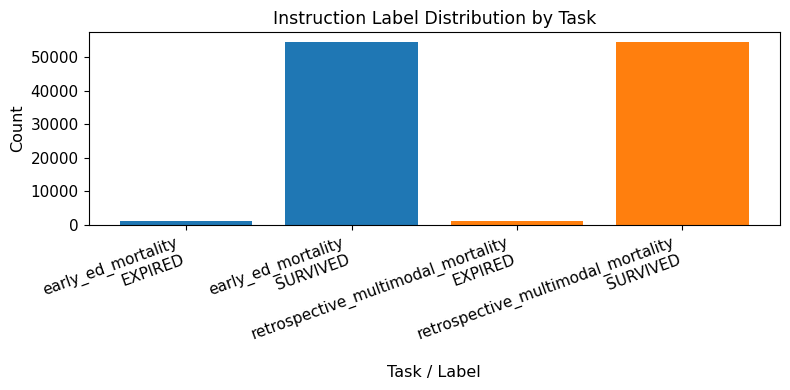

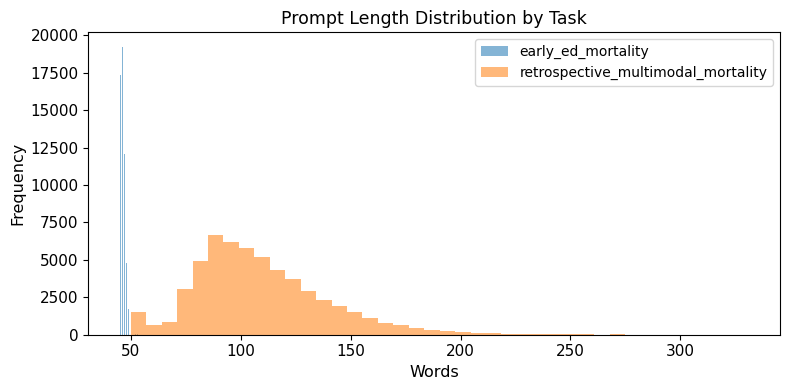

Saved legacy Llama3-Med JSON : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\outputs\instruction_dataset_llama3med.json
Saved combined profile CSV   : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\instruction_llama3med_profile.csv
Saved label plot             : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\instruction_llama3med_label_distribution.png
Saved length plot            : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\instruction_llama3med_prompt_length.png
Saved payload                : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\instruction_llama3med_payload_04.json


In [7]:
# Step 4: Llama3-Med Conversation Packaging and Dataset Visualization

print("Building Llama3-Med style conversation datasets...")

# -----------------------------------------------------------------
# 0) Guard: upstream dependencies must be present
# -----------------------------------------------------------------
task_frames = {}

if "df_instruction_early" in globals() and isinstance(df_instruction_early, pd.DataFrame) and len(df_instruction_early) > 0:
    task_frames["early_ed_mortality"] = {
        "df": df_instruction_early.copy(),
        "prefix": "instruction_llama3med_early_ed_04",
        "json_path": OUTPUTS_DIR / "instruction_dataset_llama3med_early_ed_04.json",
    }

if "df_instruction_retrospective" in globals() and isinstance(df_instruction_retrospective, pd.DataFrame) and len(df_instruction_retrospective) > 0:
    task_frames["retrospective_multimodal_mortality"] = {
        "df": df_instruction_retrospective.copy(),
        "prefix": "instruction_llama3med_retrospective_04",
        "json_path": OUTPUTS_DIR / "instruction_dataset_llama3med_retrospective_04.json",
    }

# Backward-compatible fallback.
if not task_frames:
    if "df_cohort_supervised" not in globals():
        raise RuntimeError("No instruction dataframe found. Run previous steps first.")

    required_cols = {"instruction", "input", "output"}
    if not required_cols.issubset(df_cohort_supervised.columns):
        raise RuntimeError("Required instruction columns are missing. Run prompt-engineering step first.")

    task_frames["retrospective_multimodal_mortality"] = {
        "df": df_cohort_supervised.copy(),
        "prefix": "instruction_llama3med_retrospective_04",
        "json_path": OUTPUTS_DIR / "instruction_dataset_llama3med_retrospective_04.json",
    }

required_cols = {"instruction", "input", "output"}

# -----------------------------------------------------------------
# 1) Helper: build Llama3-Med records for one task
# -----------------------------------------------------------------
def build_llama3med_records(df_conv: pd.DataFrame, task_variant: str) -> tuple:
    missing = required_cols - set(df_conv.columns)
    if missing:
        raise RuntimeError(f"{task_variant} is missing required columns: {sorted(missing)}")

    df_conv = df_conv.copy().reset_index(drop=True)

    image_col = next(
        (c for c in ["expected_image_path", "image_path", "image", "path"] if c in df_conv.columns),
        None,
    )

    if image_col is not None:
        image_series = df_conv[image_col].fillna("").astype(str).str.strip()
        has_image = image_series.str.len() > 0
    else:
        image_series = pd.Series("", index=df_conv.index)
        has_image = pd.Series(False, index=df_conv.index)

    has_subject_cols = "subject_id" in df_conv.columns and "stay_id" in df_conv.columns

    has_img_vals = has_image.values.tolist()
    img_vals = image_series.values.tolist()
    instr_vals = df_conv["instruction"].fillna("").astype(str).tolist()
    input_vals = df_conv["input"].fillna("").astype(str).tolist()
    output_vals = df_conv["output"].fillna("").astype(str).tolist()

    if has_subject_cols:
        sid_vals = df_conv["subject_id"].astype(str).tolist()
        stid_vals = df_conv["stay_id"].astype(str).tolist()
        ids = [f"{task_variant}_sid_{sid_vals[i]}_stay_{stid_vals[i]}_{i}" for i in range(len(df_conv))]
    else:
        ids = [f"{task_variant}_sample_{i}" for i in range(len(df_conv))]

    split_vals = (
        df_conv["split"].fillna("unspecified").astype(str).tolist()
        if "split" in df_conv.columns
        else ["unspecified"] * len(df_conv)
    )

    records = [
        {
            "id": ids[i],
            "task_variant": task_variant,
            "split": split_vals[i],
            "conversations": [
                {
                    "from": "human",
                    "value": (
                        ("<image>\n" if has_img_vals[i] else "")
                        + f"{instr_vals[i].strip()}\n\n{input_vals[i].strip()}"
                    ),
                },
                {
                    "from": "gpt",
                    "value": output_vals[i].strip(),
                },
            ],
            **({"image": [img_vals[i]]} if has_img_vals[i] else {}),
        }
        for i in range(len(df_conv))
    ]

    if len(records) == 0:
        raise RuntimeError(f"No records were generated for {task_variant}.")

    df_profile = pd.DataFrame({
        "sample_id": [r["id"] for r in records],
        "task_variant": task_variant,
        "split": [r.get("split", "unspecified") for r in records],
        "has_image": [int("image" in r) for r in records],
        "prompt_word_count": [len(r["conversations"][0]["value"].split()) for r in records],
        "response_word_count": [len(r["conversations"][1]["value"].split()) for r in records],
        "label_class": [
            "EXPIRED" if "EXPIRED" in r["conversations"][1]["value"].upper() else "SURVIVED"
            for r in records
        ],
    })

    return records, df_profile

# -----------------------------------------------------------------
# 2) Build and persist per-task Llama3-Med datasets
# -----------------------------------------------------------------
all_profiles = []
payload_tasks = {}

for task_variant, cfg in task_frames.items():
    records, df_profile_task = build_llama3med_records(cfg["df"], task_variant)

    with open(cfg["json_path"], "w", encoding="utf-8") as f:
        json.dump(records, f, indent=2, ensure_ascii=False)

    profile_path = QUALITY_DIR / f"{cfg['prefix']}_profile.csv"
    df_profile_task.to_csv(profile_path, index=False)

    all_profiles.append(df_profile_task)

    payload_tasks[task_variant] = {
        "records_total": int(len(records)),
        "records_with_image": int(df_profile_task["has_image"].sum()),
        "label_expired_count": int((df_profile_task["label_class"] == "EXPIRED").sum()),
        "label_survived_count": int((df_profile_task["label_class"] == "SURVIVED").sum()),
        "avg_prompt_word_count": round(float(df_profile_task["prompt_word_count"].mean()), 4),
        "avg_response_word_count": round(float(df_profile_task["response_word_count"].mean()), 4),
        "json_path": str(cfg["json_path"]),
        "profile_csv": str(profile_path),
        "split_counts": df_profile_task["split"].value_counts().to_dict(),
    }

    print(f"Saved {task_variant} Llama3-Med JSON: {cfg['json_path']}")
    print(f"Saved {task_variant} profile CSV    : {profile_path}")

# -----------------------------------------------------------------
# 3) Backward-compatible legacy output
# -----------------------------------------------------------------
# Existing downstream notebooks expect this filename.
# Preserve prior behavior by making it the retrospective conversation dataset.
legacy_llama3med_json_path = OUTPUTS_DIR / "instruction_dataset_llama3med.json"

if "retrospective_multimodal_mortality" in task_frames:
    legacy_source_path = task_frames["retrospective_multimodal_mortality"]["json_path"]
else:
    legacy_source_path = next(iter(task_frames.values()))["json_path"]

with open(legacy_source_path, "r", encoding="utf-8") as f:
    legacy_records = json.load(f)

with open(legacy_llama3med_json_path, "w", encoding="utf-8") as f:
    json.dump(legacy_records, f, indent=2, ensure_ascii=False)

# -----------------------------------------------------------------
# 4) Combined profile and visualizations
# -----------------------------------------------------------------
df_profile = pd.concat(all_profiles, ignore_index=True)

profile_csv_path = QUALITY_DIR / "instruction_llama3med_profile.csv"
label_plot_path = QUALITY_DIR / "instruction_llama3med_label_distribution.png"
length_plot_path = QUALITY_DIR / "instruction_llama3med_prompt_length.png"
payload_path = QUALITY_DIR / "instruction_llama3med_payload_04.json"

df_profile.to_csv(profile_csv_path, index=False)

display(df_profile.head())
print(f"Conversation records generated: {len(df_profile):,}")

# Label distribution by task.
label_counts = (
    df_profile
    .groupby(["task_variant", "label_class"], dropna=False)
    .size()
    .reset_index(name="count")
)

plt.figure(figsize=(8, 4))
for task_variant in label_counts["task_variant"].unique():
    sub = label_counts[label_counts["task_variant"] == task_variant]
    plt.bar(
        sub["task_variant"] + "\n" + sub["label_class"],
        sub["count"],
    )

plt.title("Instruction Label Distribution by Task")
plt.xlabel("Task / Label")
plt.ylabel("Count")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(label_plot_path, dpi=220, bbox_inches="tight")
plt.show()

# Prompt length distribution by task.
plt.figure(figsize=(8, 4))
for task_variant, sub in df_profile.groupby("task_variant"):
    plt.hist(
        sub["prompt_word_count"],
        bins=40,
        alpha=0.55,
        label=task_variant,
    )

plt.title("Prompt Length Distribution by Task")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.savefig(length_plot_path, dpi=220, bbox_inches="tight")
plt.show()

# -----------------------------------------------------------------
# 5) Persist audit payload
# -----------------------------------------------------------------
save_step_payload({
    "legacy_json": str(legacy_llama3med_json_path),
    "legacy_default_variant": "retrospective_multimodal_mortality",
    "combined_profile_csv": str(profile_csv_path),
    "label_plot": str(label_plot_path),
    "length_plot": str(length_plot_path),
    "tasks": payload_tasks,
}, payload_path)

print(f"Saved legacy Llama3-Med JSON : {legacy_llama3med_json_path}")
print(f"Saved combined profile CSV   : {profile_csv_path}")
print(f"Saved label plot             : {label_plot_path}")
print(f"Saved length plot            : {length_plot_path}")
print(f"Saved payload                : {payload_path}")


**Step 5: CLIP Linkage Bridge for Instruction Dataset**

This step links instruction records to CLIP image-embedding metadata generated in Notebook 03 when available. It attempts to join instruction rows with the CLIP index using shared identifiers such as `dicom_id`, `study_id`, `stay_id`, or `subject_id`.

**Main Operations**  
◽ Resolve task-aware instruction dataframes  
◽ Locate the CLIP embedding index from Notebook 03  
◽ Join instruction rows to CLIP metadata using the best available shared identifier  
◽ Add `clip_embedding_row` and image-reference fields when linkage is possible  
◽ Track linkage mode, linked-row count, and missing-embedding rows  
◽ Export task-specific CLIP bridge JSONL files  
◽ Save audit, preview, compatibility, and payload artifacts  

**Technical and Clinical Significance**  
This step creates the bridge between language instructions and image embeddings. Keeping the linkage audit explicit ensures that downstream multimodal models can distinguish between records with valid image-embedding references and records that remain text-only.

**Expected Outcome**  
CLIP-linked instruction bridge files and audit artifacts are saved for multimodal alignment and image-text training workflows.

In [8]:
# Step 5: CLIP Linkage Bridge for Instruction Dataset (Audit-First)

print("Starting Step 5: Task-aware CLIP linkage bridge for Notebook 04...")

# -----------------------------------------------------------------
# 0) Resolve task-aware instruction dataframes
# -----------------------------------------------------------------
task_frames = {}

if "df_instruction_early" in globals() and isinstance(df_instruction_early, pd.DataFrame) and len(df_instruction_early) > 0:
    task_frames["early_ed_mortality"] = {
        "df": df_instruction_early.copy(),
        "prefix": "instruction_clip_linkage_early_ed_04",
    }

if "df_instruction_retrospective" in globals() and isinstance(df_instruction_retrospective, pd.DataFrame) and len(df_instruction_retrospective) > 0:
    task_frames["retrospective_multimodal_mortality"] = {
        "df": df_instruction_retrospective.copy(),
        "prefix": "instruction_clip_linkage_retrospective_04",
    }

# Backward-compatible fallback.
if not task_frames:
    df_instr, source_name = resolve_instruction_df(step_label="Step 5: CLIP Linkage")
    task_name = (
        str(df_instr["task_variant"].iloc[0])
        if "task_variant" in df_instr.columns and len(df_instr) > 0
        else "legacy_instruction_dataset"
    )
    task_frames[task_name] = {
        "df": df_instr.copy(),
        "prefix": "instruction_clip_linkage_04",
    }

print(f"Instruction task sources detected: {len(task_frames)}")

# -----------------------------------------------------------------
# 1) Locate CLIP index artifact from Notebook 03
# -----------------------------------------------------------------
clip_index_candidates = [
    ARTIFACTS["clip_index_primary"],
    ARTIFACTS["clip_index_fallback"],
]
clip_index_path = next((p for p in clip_index_candidates if p.exists()), None)

if clip_index_path is None:
    print("CLIP index not found. Run Notebook 03 Step 5 later to enable full CLIP linkage.")
    df_clip = None
else:
    df_clip = pd.read_csv(clip_index_path)
    print(f"CLIP index found: {clip_index_path} (rows={len(df_clip):,})")

# -----------------------------------------------------------------
# 2) Helper: link one instruction dataframe to CLIP index
# -----------------------------------------------------------------
def link_instruction_to_clip(df_instr: pd.DataFrame, task_variant: str) -> tuple:
    df_linked = df_instr.copy()

    if "clip_embedding_row" not in df_linked.columns:
        df_linked["clip_embedding_row"] = pd.NA

    join_mode = "no_clip_index"

    if df_clip is not None:
        key_priority = ["dicom_id", "study_id", "stay_id", "subject_id"]
        join_key = next(
            (k for k in key_priority if k in df_linked.columns and k in df_clip.columns),
            None,
        )

        if join_key is not None:
            df_linked[join_key] = df_linked[join_key].astype(str)
            clip_work = df_clip.copy()
            clip_work[join_key] = clip_work[join_key].astype(str)

            merge_cols = [
                c for c in [join_key, "clip_embedding_row", "dicom_id", "study_id", "expected_image_path", "image_path"]
                if c in clip_work.columns
            ]

            df_linked = df_linked.merge(
                clip_work[merge_cols].drop_duplicates(),
                on=join_key,
                how="left",
                suffixes=("", "_clip"),
            )

            if "clip_embedding_row_clip" in df_linked.columns:
                df_linked["clip_embedding_row"] = df_linked["clip_embedding_row"].combine_first(
                    df_linked["clip_embedding_row_clip"]
                )
                df_linked = df_linked.drop(columns=["clip_embedding_row_clip"])

            join_mode = f"key:{join_key}"
        else:
            join_mode = "clip_index_present_no_shared_key"

    df_linked["clip_embedding_available"] = df_linked["clip_embedding_row"].notna().astype(int)

    df_linked["contains_image_token"] = (
        df_linked["input"].fillna("").astype(str).str.contains("<image>", regex=False).astype(int)
        if "input" in df_linked.columns
        else 0
    )

    df_linked["task_variant"] = task_variant

    coverage_pct = float(df_linked["clip_embedding_available"].mean() * 100.0)

    audit_df = pd.DataFrame([
        {"task_variant": task_variant, "metric": "instruction_rows", "value": int(len(df_linked))},
        {"task_variant": task_variant, "metric": "join_mode", "value": join_mode},
        {
            "task_variant": task_variant,
            "metric": "rows_with_clip_embedding",
            "value": int(df_linked["clip_embedding_available"].sum()),
        },
        {
            "task_variant": task_variant,
            "metric": "clip_linkage_coverage_pct",
            "value": round(coverage_pct, 4),
        },
        {
            "task_variant": task_variant,
            "metric": "rows_with_image_token",
            "value": int(df_linked["contains_image_token"].sum()),
        },
    ])

    summary_payload = {
        "task_variant": task_variant,
        "clip_index_path": str(clip_index_path) if clip_index_path else None,
        "join_mode": join_mode,
        "rows": int(len(df_linked)),
        "rows_with_clip_embedding": int(df_linked["clip_embedding_available"].sum()),
        "coverage_pct": round(coverage_pct, 4),
    }

    return df_linked, audit_df, summary_payload

# -----------------------------------------------------------------
# 3) Run linkage per task and persist task-specific artifacts
# -----------------------------------------------------------------
linked_frames = {}
audit_frames = []
payload_tasks = {}

for task_variant, cfg in task_frames.items():
    print(f"\nLinking task: {task_variant}")

    df_linked, audit_df, summary_payload = link_instruction_to_clip(
        cfg["df"],
        task_variant=task_variant,
    )

    linked_frames[task_variant] = df_linked
    audit_frames.append(audit_df)
    payload_tasks[task_variant] = summary_payload

    export_cols = [
        c for c in [
            "instruction",
            "input",
            "output",
            "task_variant",
            "split",
            "subject_id",
            "stay_id",
            "study_id",
            "dicom_id",
            "clip_embedding_row",
            "clip_embedding_available",
            "contains_image_token",
            "uses_clinical_text",
            "has_clinical_text",
        ]
        if c in df_linked.columns
    ]

    preview_cols = export_cols.copy()

    paths = export_step_artifacts(
        export_df=df_linked[export_cols],
        audit_df=audit_df,
        summary_payload=summary_payload,
        prefix=cfg["prefix"],
    )

    preview_path = QUALITY_DIR / f"{cfg['prefix']}_preview.csv"
    df_linked[preview_cols].head(3000).to_csv(preview_path, index=False)

    print(f"Saved CLIP linkage audit   : {paths['audit']}")
    print(f"Saved CLIP linkage preview : {preview_path}")
    print(f"Saved CLIP bridge dataset  : {paths['export']}")
    print(f"Saved CLIP linkage payload : {paths['payload']}")

# -----------------------------------------------------------------
# 4) Backward-compatible legacy outputs
# -----------------------------------------------------------------
# Preserve existing behavior: legacy CLIP bridge points to retrospective variant.
legacy_task = (
    "retrospective_multimodal_mortality"
    if "retrospective_multimodal_mortality" in linked_frames
    else next(iter(linked_frames.keys()))
)

legacy_df = linked_frames[legacy_task].copy()

legacy_export_cols = [
    c for c in [
        "instruction",
        "input",
        "output",
        "task_variant",
        "split",
        "subject_id",
        "stay_id",
        "study_id",
        "dicom_id",
        "clip_embedding_row",
        "clip_embedding_available",
        "contains_image_token",
        "uses_clinical_text",
        "has_clinical_text",
    ]
    if c in legacy_df.columns
]

legacy_audit_df = pd.concat(audit_frames, ignore_index=True)

legacy_paths = export_step_artifacts(
    export_df=legacy_df[legacy_export_cols],
    audit_df=legacy_audit_df,
    summary_payload={
        "legacy_default_variant": legacy_task,
        "clip_index_path": str(clip_index_path) if clip_index_path else None,
        "tasks": payload_tasks,
    },
    prefix="instruction_clip_linkage_04",
)

# Extra compatibility alias for resolver fallback naming.
compat_bridge_path = OUTPUTS_DIR / "instruction_dataset_clip_bridge_04.jsonl"
legacy_df[legacy_export_cols].to_json(
    compat_bridge_path,
    orient="records",
    lines=True,
    force_ascii=False,
)

legacy_preview_path = QUALITY_DIR / "instruction_clip_linkage_preview_04.csv"
legacy_df[legacy_export_cols].head(3000).to_csv(legacy_preview_path, index=False)

print("\nSaved legacy CLIP linkage outputs.")
print(f"Legacy default variant       : {legacy_task}")
print(f"Legacy audit                 : {legacy_paths['audit']}")
print(f"Legacy preview               : {legacy_preview_path}")
print(f"Legacy bridge dataset        : {legacy_paths['export']}")
print(f"Compatibility bridge dataset : {compat_bridge_path}")
print(f"Legacy payload               : {legacy_paths['payload']}")

display(legacy_audit_df)


Starting Step 5: Task-aware CLIP linkage bridge for Notebook 04...
Instruction task sources detected: 2
CLIP index not found. Run Notebook 03 Step 5 later to enable full CLIP linkage.

Linking task: early_ed_mortality
Saved CLIP linkage audit   : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\instruction_clip_linkage_early_ed_04_audit.csv
Saved CLIP linkage preview : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\instruction_clip_linkage_early_ed_04_preview.csv
Saved CLIP bridge dataset  : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\outputs\instruction_clip_linkage_early_ed_04.jsonl
Saved CLIP linkage payload : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\instruction_clip_linkage_early_ed_04_payload.json

Linking task: retrospective_multimodal_mortality
Saved CLIP linkage audit   : C:\Users\927997\OneDrive -

,task_variant,metric,value
0,early_ed_mortality,instruction_rows,55891
1,early_ed_mortality,join_mode,no_clip_index
2,early_ed_mortality,rows_with_clip_embedding,0
3,early_ed_mortality,clip_linkage_coverage_pct,0.0
4,early_ed_mortality,rows_with_image_token,0
5,retrospective_multimodal_mortality,instruction_rows,55891
6,retrospective_multimodal_mortality,join_mode,no_clip_index
7,retrospective_multimodal_mortality,rows_with_clip_embedding,0
8,retrospective_multimodal_mortality,clip_linkage_coverage_pct,0.0
9,retrospective_multimodal_mortality,rows_with_image_token,0


**Step 6: CPLLM-Inspired Concept-Enriched Instruction Packaging**

This step enriches instruction records with clinical concept cues. It loads the clinical term bank from earlier preprocessing outputs when available, falls back to a small predefined term list when needed, and appends matched concepts to the instruction input.

**Main Operations**  
◽ Resolve task-aware instruction dataframes  
◽ Load the clinical term bank from Notebook 02 artifacts when available  
◽ Use a fallback minimal concept bank if no external term bank is found  
◽ Match clinical terms against each instruction input  
◽ Add concept-enriched input fields and concept-count metadata  
◽ Export concept-augmented JSONL files  
◽ Save concept-coverage summaries, previews, compatibility exports, and payload files  

**Technical and Clinical Significance**  
Concept enrichment makes clinical cues more explicit for later instruction tuning and analysis. This can help inspect whether important clinical concepts are present in the prompt and can support concept-aware reasoning or ablation experiments.

**Expected Outcome**  
CPLLM-style concept-augmented instruction datasets and concept-coverage audit files are generated.

In [9]:
# Step 6: CPLLM-Inspired Concept-Enriched Instruction Packaging (Audit-First)

print("Starting Step 6: Task-aware CPLLM-inspired concept enrichment for instructions...")

# -----------------------------------------------------------------
# 0) Resolve task-aware instruction dataframes
# -----------------------------------------------------------------
task_frames = {}

if "df_instruction_early" in globals() and isinstance(df_instruction_early, pd.DataFrame) and len(df_instruction_early) > 0:
    task_frames["early_ed_mortality"] = {
        "df": df_instruction_early.copy(),
        "prefix": "cpllm_instruction_concept_early_ed_04",
    }

if "df_instruction_retrospective" in globals() and isinstance(df_instruction_retrospective, pd.DataFrame) and len(df_instruction_retrospective) > 0:
    task_frames["retrospective_multimodal_mortality"] = {
        "df": df_instruction_retrospective.copy(),
        "prefix": "cpllm_instruction_concept_retrospective_04",
    }

# Backward-compatible fallback.
if not task_frames:
    df_instr, source_name = resolve_instruction_df(step_label="Step 6: CPLLM Enrichment")
    task_name = (
        str(df_instr["task_variant"].iloc[0])
        if "task_variant" in df_instr.columns and len(df_instr) > 0
        else "legacy_instruction_dataset"
    )
    task_frames[task_name] = {
        "df": df_instr.copy(),
        "prefix": "cpllm_instruction_concept_04",
    }

print(f"Instruction task sources detected: {len(task_frames)}")

# -----------------------------------------------------------------
# 1) Load term bank from Notebook 02 artifacts
# -----------------------------------------------------------------
term_bank = []
term_csv = ARTIFACTS["cpllm_term_bank_csv"]
term_json = ARTIFACTS["cpllm_term_bank_json"]

term_source = None

if term_csv.exists():
    df_terms = pd.read_csv(term_csv)
    if "term" in df_terms.columns:
        term_bank.extend(df_terms["term"].dropna().astype(str).tolist())
        term_source = str(term_csv)

if (not term_bank) and term_json.exists():
    try:
        with open(term_json, "r", encoding="utf-8") as fh:
            _payload = json.load(fh)
        term_bank.extend([
            str(x.get("term", ""))
            for x in _payload.get("terms", [])
            if str(x.get("term", "")).strip()
        ])
        term_source = str(term_json)
    except Exception:
        pass

# -----------------------------------------------------------------
# 2) Fallback minimal concept bank
# -----------------------------------------------------------------
if not term_bank:
    term_bank = [
        "septic shock",
        "pulmonary edema",
        "tachycardia",
        "hypotension",
        "acute kidney injury",
    ]
    term_source = "fallback_minimal_term_bank"

# -----------------------------------------------------------------
# 3) Deduplicate, trim, compile pattern cache
# -----------------------------------------------------------------
term_bank = sorted({
    t.strip().lower()
    for t in term_bank
    if 3 <= len(str(t).strip()) <= 80
})[:3000]

pattern_cache = {
    t: re.compile(rf"\b{re.escape(t)}\b", flags=re.IGNORECASE)
    for t in term_bank
}

def _matched_terms(text: str, max_k: int = 5) -> list:
    text = str(text)
    hits = []
    for t, pat in pattern_cache.items():
        if pat.search(text):
            hits.append(t)
            if len(hits) >= max_k:
                break
    return hits


def _augment_input(inp: str, terms: list) -> str:
    if not terms:
        return str(inp)
    hint = " | ".join(terms[:5])
    return f"{str(inp).strip()}\n\nClinical Concept Hints: {hint}"


def enrich_with_cpllm_concepts(df_instr: pd.DataFrame, task_variant: str) -> tuple:
    df_enriched = df_instr.copy()
    df_enriched = ensure_base_instruction_columns(df_enriched)

    combined_text = (
        df_enriched["instruction"].fillna("").astype(str)
        + " "
        + df_enriched["input"].fillna("").astype(str)
    )

    df_enriched["cpllm_matched_terms"] = combined_text.map(_matched_terms)
    df_enriched["cpllm_match_count"] = df_enriched["cpllm_matched_terms"].map(len)
    df_enriched["cpllm_has_match"] = (df_enriched["cpllm_match_count"] > 0).astype(int)

    df_enriched["input_cpllm_augmented"] = [
        _augment_input(inp, terms)
        for inp, terms in zip(
            df_enriched["input"].tolist(),
            df_enriched["cpllm_matched_terms"].tolist(),
        )
    ]

    df_enriched["task_variant"] = task_variant

    coverage_pct = float(df_enriched["cpllm_has_match"].mean() * 100.0)

    summary_df = pd.DataFrame([
        {"task_variant": task_variant, "metric": "rows", "value": int(len(df_enriched))},
        {"task_variant": task_variant, "metric": "term_bank_size", "value": int(len(term_bank))},
        {
            "task_variant": task_variant,
            "metric": "rows_with_matched_terms",
            "value": int(df_enriched["cpllm_has_match"].sum()),
        },
        {
            "task_variant": task_variant,
            "metric": "coverage_pct",
            "value": round(coverage_pct, 4),
        },
        {
            "task_variant": task_variant,
            "metric": "uses_clinical_text",
            "value": int(df_enriched["uses_clinical_text"].max())
            if "uses_clinical_text" in df_enriched.columns else "NA",
        },
        {
            "task_variant": task_variant,
            "metric": "rows_with_clinical_text",
            "value": int(df_enriched["has_clinical_text"].sum())
            if "has_clinical_text" in df_enriched.columns else "NA",
        },
    ])

    payload = {
        "task_variant": task_variant,
        "rows": int(len(df_enriched)),
        "term_bank_size": int(len(term_bank)),
        "term_source": term_source,
        "coverage_pct": round(coverage_pct, 4),
        "rows_with_matched_terms": int(df_enriched["cpllm_has_match"].sum()),
    }

    return df_enriched, summary_df, payload

# -----------------------------------------------------------------
# 4) Run enrichment per task
# -----------------------------------------------------------------
enriched_frames = {}
summary_frames = []
payload_tasks = {}

for task_variant, cfg in task_frames.items():
    print(f"\nEnriching task: {task_variant}")

    df_enriched, summary_df, payload = enrich_with_cpllm_concepts(
        cfg["df"],
        task_variant=task_variant,
    )

    enriched_frames[task_variant] = df_enriched
    summary_frames.append(summary_df)
    payload_tasks[task_variant] = payload

    export_cols = [
        c for c in [
            "instruction",
            "input",
            "input_cpllm_augmented",
            "output",
            "task_variant",
            "split",
            "subject_id",
            "stay_id",
            "study_id",
            "dicom_id",
            "uses_clinical_text",
            "has_clinical_text",
            "cpllm_matched_terms",
            "cpllm_match_count",
            "cpllm_has_match",
        ]
        if c in df_enriched.columns
    ]

    preview_cols = [
        c for c in [
            "instruction",
            "input",
            "input_cpllm_augmented",
            "output",
            "task_variant",
            "split",
            "cpllm_match_count",
            "cpllm_has_match",
            "uses_clinical_text",
            "has_clinical_text",
        ]
        if c in df_enriched.columns
    ]

    paths = export_step_artifacts(
        export_df=df_enriched[export_cols],
        audit_df=summary_df,
        summary_payload=payload,
        prefix=cfg["prefix"],
    )

    preview_path = QUALITY_DIR / f"{cfg['prefix']}_preview.csv"
    df_enriched[preview_cols].head(3000).to_csv(preview_path, index=False)

    print(f"Saved concept coverage summary : {paths['audit']}")
    print(f"Saved concept preview          : {preview_path}")
    print(f"Saved concept-augmented JSONL  : {paths['export']}")
    print(f"Saved concept payload          : {paths['payload']}")

# -----------------------------------------------------------------
# 5) Backward-compatible legacy outputs
# -----------------------------------------------------------------
legacy_task = (
    "retrospective_multimodal_mortality"
    if "retrospective_multimodal_mortality" in enriched_frames
    else next(iter(enriched_frames.keys()))
)

legacy_df = enriched_frames[legacy_task].copy()
combined_summary_df = pd.concat(summary_frames, ignore_index=True)

legacy_export_cols = [
    c for c in [
        "instruction",
        "input",
        "input_cpllm_augmented",
        "output",
        "task_variant",
        "split",
        "subject_id",
        "stay_id",
        "study_id",
        "dicom_id",
        "uses_clinical_text",
        "has_clinical_text",
        "cpllm_matched_terms",
        "cpllm_match_count",
        "cpllm_has_match",
    ]
    if c in legacy_df.columns
]

legacy_paths = export_step_artifacts(
    export_df=legacy_df[legacy_export_cols],
    audit_df=combined_summary_df,
    summary_payload={
        "legacy_default_variant": legacy_task,
        "term_source": term_source,
        "term_bank_size": int(len(term_bank)),
        "tasks": payload_tasks,
    },
    prefix="cpllm_instruction_concept_04",
)

# Compatibility alias expected by resolver.
compat_augmented_path = OUTPUTS_DIR / "instruction_dataset_cpllm_augmented_04.jsonl"
legacy_df[legacy_export_cols].to_json(
    compat_augmented_path,
    orient="records",
    lines=True,
    force_ascii=False,
)

legacy_preview_path = QUALITY_DIR / "cpllm_instruction_concept_preview_04.csv"
legacy_df[legacy_export_cols].head(3000).to_csv(legacy_preview_path, index=False)

print("\nSaved legacy CPLLM concept outputs.")
print(f"Legacy default variant            : {legacy_task}")
print(f"Legacy concept coverage summary   : {legacy_paths['audit']}")
print(f"Legacy concept preview            : {legacy_preview_path}")
print(f"Legacy concept-augmented JSONL    : {legacy_paths['export']}")
print(f"Compatibility augmented JSONL     : {compat_augmented_path}")
print(f"Legacy concept payload            : {legacy_paths['payload']}")

display(combined_summary_df)


Starting Step 6: Task-aware CPLLM-inspired concept enrichment for instructions...
Instruction task sources detected: 2

Enriching task: early_ed_mortality
Saved concept coverage summary : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\cpllm_instruction_concept_early_ed_04_audit.csv
Saved concept preview          : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\cpllm_instruction_concept_early_ed_04_preview.csv
Saved concept-augmented JSONL  : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\outputs\cpllm_instruction_concept_early_ed_04.jsonl
Saved concept payload          : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\cpllm_instruction_concept_early_ed_04_payload.json

Enriching task: retrospective_multimodal_mortality
Saved concept coverage summary : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM D

,task_variant,metric,value
0,early_ed_mortality,rows,55891.0
1,early_ed_mortality,term_bank_size,3000.0
2,early_ed_mortality,rows_with_matched_terms,55891.0
3,early_ed_mortality,coverage_pct,100.0
4,early_ed_mortality,uses_clinical_text,0.0
5,early_ed_mortality,rows_with_clinical_text,55891.0
6,retrospective_multimodal_mortality,rows,55891.0
7,retrospective_multimodal_mortality,term_bank_size,3000.0
8,retrospective_multimodal_mortality,rows_with_matched_terms,55891.0
9,retrospective_multimodal_mortality,coverage_pct,100.0


**Step 7: MedTVT-R1 Multimodal Instruction Schema and Chain-of-Evidence Tagging**

This step prepares instruction records for MedTVT-R1 style multimodal training. It inserts modality tokens such as `<lab>`, `<cxr>`, and `<ecg>` when supported by the available data, and wraps assistant outputs with Chain-of-Evidence style reasoning tags.

**Main Operations**  
◽ Resolve early ED and retrospective instruction dataframes  
◽ Detect available modality evidence from structured clinical features, image paths, and optional ECG fields  
◽ Add modality tokens without claiming unavailable modalities  
◽ Ensure assistant outputs follow `<think>` and `<answer>` tagging structure  
◽ Build MedTVT-ready instruction records with modality metadata  
◽ Export task-specific and compatibility JSONL files  
◽ Save schema-compliance audits, previews, and payload summaries  

**Technical and Clinical Significance**  
This step creates a structured multimodal instruction schema while keeping modality claims conservative. Chain-of-Evidence tagging also separates reasoning text from final answers, which supports later explainability-focused evaluation.

**Expected Outcome**  
MedTVT-R1 ready instruction datasets, schema audits, previews, and payload files are saved.

In [10]:
# ======================================================================
# Step 7: MedTVT-R1-Inspired Multimodal Instruction Schema + CoE Tagging
# ======================================================================

print("Starting Step 7: Task-aware MedTVT-R1 multimodal schema packaging...")

# -----------------------------------------------------------------
# 0) Resolve task-aware instruction dataframes
# -----------------------------------------------------------------
task_frames = {}

if "df_instruction_early" in globals() and isinstance(df_instruction_early, pd.DataFrame) and len(df_instruction_early) > 0:
    task_frames["early_ed_mortality"] = {
        "df": df_instruction_early.copy(),
        "prefix": "medtvt_instruction_early_ed_04",
    }

if "df_instruction_retrospective" in globals() and isinstance(df_instruction_retrospective, pd.DataFrame) and len(df_instruction_retrospective) > 0:
    task_frames["retrospective_multimodal_mortality"] = {
        "df": df_instruction_retrospective.copy(),
        "prefix": "medtvt_instruction_retrospective_04",
    }

# Backward-compatible fallback.
if not task_frames:
    df_instr, source_name = resolve_instruction_df(step_label="Step 7: MedTVT Schema")
    task_name = (
        str(df_instr["task_variant"].iloc[0])
        if "task_variant" in df_instr.columns and len(df_instr) > 0
        else "legacy_instruction_dataset"
    )
    task_frames[task_name] = {
        "df": df_instr.copy(),
        "prefix": "medtvt_instruction_04",
    }

print(f"Instruction task sources detected: {len(task_frames)}")

# -----------------------------------------------------------------
# 1) Compile patterns
# -----------------------------------------------------------------
coe_pattern = re.compile(
    r"<think>.*?</think>\s*<answer>.*?</answer>",
    flags=re.IGNORECASE | re.DOTALL,
)

ecg_cols = ["ecg_path", "ECG", "ecg_file", "ecg_ref"]
cxr_cols = ["cxr_path", "CXR", "expected_image_path", "image_path", "cxr_file", "cxr_ref"]
lab_cols = ["lab_path", "LAB", "lab_values", "lab_ref"]

# -----------------------------------------------------------------
# 2) Step-local helper functions
# -----------------------------------------------------------------
def _available_modalities_for_task(df: pd.DataFrame, task_variant: str) -> list:
    """
    Avoid claiming unavailable modalities.
    Early ED gets <lab> only by default because triage vitals are structured clinical signals.
    Retrospective gets <lab> + <cxr> when radiology text/image linkage is present.
    <ecg> is only added if ECG columns exist.
    """
    modalities = ["<lab>"]

    has_ecg = any(c in df.columns and df[c].fillna("").astype(str).str.strip().ne("").any() for c in ecg_cols)
    if has_ecg:
        modalities.append("<ecg>")

    if task_variant == "retrospective_multimodal_mortality":
        modalities.append("<cxr>")
    else:
        has_cxr_path = any(c in df.columns and df[c].fillna("").astype(str).str.strip().ne("").any() for c in cxr_cols)
        if has_cxr_path:
            modalities.append("<cxr>")

    return modalities


def _ensure_modality_tokens(text: str, modalities: list) -> str:
    x = str(text).strip()
    x_lower = x.lower()
    missing = [tok for tok in modalities if tok not in x_lower]
    if not missing:
        return x
    return (x + " Available modalities: " + " ".join(modalities) + ".").strip()


def _ensure_coe_tags(answer_text: str, modalities: list) -> str:
    text = str(answer_text).strip()
    if coe_pattern.fullmatch(text):
        return text

    sanitized = re.sub(r"\s+", " ", text).strip()
    if not sanitized:
        sanitized = "Insufficient evidence provided."

    modality_text = ", ".join([m.strip("<>") for m in modalities]) if modalities else "available clinical evidence"
    think_block = f"Clinical reasoning synthesized from {modality_text} evidence."
    return f"<think>{think_block}</think><answer>{sanitized}</answer>"


def _pick_row_value_by_index(df: pd.DataFrame, idx: int, candidates: list) -> str:
    for c in candidates:
        if c in df.columns:
            val = str(df[c].iat[idx]).strip()
            if val and val.lower() != "nan":
                return val
    return "NA"


def build_medtvt_pack(df_instr: pd.DataFrame, task_variant: str) -> tuple:
    df_work = df_instr.copy()
    df_work = ensure_base_instruction_columns(df_work)

    modalities = _available_modalities_for_task(df_work, task_variant)
    all_possible_tokens = ["<ecg>", "<cxr>", "<lab>"]

    df_work["instruction_medtvt"] = df_work["instruction"].fillna("").astype(str).str.strip()
    df_work["input_medtvt"] = df_work["input"].fillna("").astype(str).map(
        lambda x: _ensure_modality_tokens(x, modalities)
    )
    df_work["output_has_coe_before"] = df_work["output"].map(
        lambda x: int(bool(coe_pattern.fullmatch(str(x).strip())))
    )
    df_work["output_medtvt"] = df_work["output"].map(
        lambda x: _ensure_coe_tags(x, modalities)
    )
    df_work["output_has_coe_after"] = df_work["output_medtvt"].map(
        lambda x: int(bool(coe_pattern.fullmatch(str(x).strip())))
    )

    combined_prompt = (df_work["instruction_medtvt"] + "\n" + df_work["input_medtvt"]).str.strip()

    for tok in all_possible_tokens:
        flag_name = f"has_{tok.strip('<>')}"
        df_work[flag_name] = (
            combined_prompt.str.lower().str.contains(re.escape(tok), regex=True).astype(int)
        )

    active_flag_cols = [f"has_{tok.strip('<>')}" for tok in modalities]
    df_work["active_modality_token_coverage"] = (
        df_work[active_flag_cols].sum(axis=1) / float(max(len(active_flag_cols), 1))
    )

    df_work["all_modality_token_coverage"] = (
        df_work[["has_ecg", "has_cxr", "has_lab"]].sum(axis=1) / 3.0
    )

    instr_vals = df_work["instruction_medtvt"].tolist()
    input_vals = df_work["input_medtvt"].tolist()
    out_vals = df_work["output_medtvt"].tolist()
    split_vals = df_work["split"].fillna("unspecified").astype(str).tolist() if "split" in df_work.columns else ["unspecified"] * len(df_work)

    records = [
        {
            "task_variant": task_variant,
            "split": split_vals[i],
            "messages": [
                {
                    "role": "user",
                    "content": f"{instr_vals[i]}\n{input_vals[i]}".strip(),
                },
                {
                    "role": "assistant",
                    "content": out_vals[i],
                },
            ],
            "ECG": _pick_row_value_by_index(df_work, i, ecg_cols),
            "CXR": _pick_row_value_by_index(df_work, i, cxr_cols),
            "LAB": _pick_row_value_by_index(df_work, i, lab_cols),
            "active_modalities": modalities,
        }
        for i in range(len(df_work))
    ]

    export_df = pd.DataFrame(records)

    audit_cols = [
        "instruction",
        "input",
        "output",
        "task_variant",
        "split",
        "output_has_coe_before",
        "output_has_coe_after",
        "has_ecg",
        "has_cxr",
        "has_lab",
        "active_modality_token_coverage",
        "all_modality_token_coverage",
        "uses_clinical_text",
        "has_clinical_text",
    ]
    audit_cols = [c for c in audit_cols if c in df_work.columns]
    audit_df = df_work[audit_cols].copy()

    summary = {
        "task_variant": task_variant,
        "rows": int(len(df_work)),
        "active_modalities": modalities,
        "coe_before_pct": round(float(df_work["output_has_coe_before"].mean() * 100.0), 4),
        "coe_after_pct": round(float(df_work["output_has_coe_after"].mean() * 100.0), 4),
        "active_modality_tokens_present_pct": round(
            float((df_work["active_modality_token_coverage"] == 1.0).mean() * 100.0), 4
        ),
        "avg_active_modality_token_coverage": round(
            float(df_work["active_modality_token_coverage"].mean() * 100.0), 4
        ),
        "avg_all_modality_token_coverage": round(
            float(df_work["all_modality_token_coverage"].mean() * 100.0), 4
        ),
    }

    return export_df, audit_df, summary

# -----------------------------------------------------------------
# 3) Build MedTVT artifacts per task
# -----------------------------------------------------------------
export_frames = {}
audit_frames = []
summary_tasks = {}

for task_variant, cfg in task_frames.items():
    print(f"\nPackaging task: {task_variant}")

    export_df, audit_df, summary = build_medtvt_pack(
        cfg["df"],
        task_variant=task_variant,
    )

    export_frames[task_variant] = export_df
    audit_frames.append(audit_df)
    summary_tasks[task_variant] = summary

    paths = export_step_artifacts(
        export_df=export_df,
        audit_df=audit_df,
        summary_payload=summary,
        prefix=cfg["prefix"],
    )

    print(f"Saved MedTVT instruction audit   : {paths['audit']}")
    print(f"Saved MedTVT instruction preview : {paths['preview']}")
    print(f"Saved MedTVT-ready JSONL         : {paths['export']}")
    print(f"Saved MedTVT payload             : {paths['payload']}")

# -----------------------------------------------------------------
# 4) Backward-compatible legacy output
# -----------------------------------------------------------------
legacy_task = (
    "retrospective_multimodal_mortality"
    if "retrospective_multimodal_mortality" in export_frames
    else next(iter(export_frames.keys()))
)

legacy_export_df = export_frames[legacy_task].copy()
combined_audit_df = pd.concat(audit_frames, ignore_index=True)

legacy_paths = export_step_artifacts(
    export_df=legacy_export_df,
    audit_df=combined_audit_df,
    summary_payload={
        "legacy_default_variant": legacy_task,
        "tasks": summary_tasks,
    },
    prefix="medtvt_instruction_04",
)

# Compatibility alias expected by some existing code.
compat_medtvt_path = OUTPUTS_DIR / "instruction_dataset_medtvt_ready_04.jsonl"
legacy_export_df.to_json(
    compat_medtvt_path,
    orient="records",
    lines=True,
    force_ascii=False,
)

print("\nSaved legacy MedTVT outputs.")
print(f"Legacy default variant       : {legacy_task}")
print(f"Legacy MedTVT audit          : {legacy_paths['audit']}")
print(f"Legacy MedTVT preview        : {legacy_paths['preview']}")
print(f"Legacy MedTVT-ready JSONL    : {legacy_paths['export']}")
print(f"Compatibility MedTVT JSONL   : {compat_medtvt_path}")
print(f"Legacy MedTVT payload        : {legacy_paths['payload']}")

display(pd.DataFrame(summary_tasks).T)


Starting Step 7: Task-aware MedTVT-R1 multimodal schema packaging...
Instruction task sources detected: 2

Packaging task: early_ed_mortality
Saved MedTVT instruction audit   : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\medtvt_instruction_early_ed_04_audit.csv
Saved MedTVT instruction preview : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\medtvt_instruction_early_ed_04_preview.csv
Saved MedTVT-ready JSONL         : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\outputs\medtvt_instruction_early_ed_04.jsonl
Saved MedTVT payload             : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\medtvt_instruction_early_ed_04_payload.json

Packaging task: retrospective_multimodal_mortality
Saved MedTVT instruction audit   : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports

,task_variant,rows,active_modalities,coe_before_pct,coe_after_pct,active_modality_tokens_present_pct,avg_active_modality_token_coverage,avg_all_modality_token_coverage
early_ed_mortality,early_ed_mortality,55891,"[<lab>, <cxr>]",0.0,100.0,100.0,100.0,66.6667
retrospective_multimodal_mortality,retrospective_multimodal_mortality,55891,"[<lab>, <cxr>]",0.0,100.0,100.0,100.0,66.6667


**Step 8: PointDetectCount Multi-Task Instruction Contract Packaging**

This step adapts instruction records into PointDetectCount-style structured output contracts. It infers whether each instruction resembles a pointing, bounding-box, counting, or combined task, then canonicalizes outputs into the expected JSON schema.

**Main Operations**  
◽ Resolve task-aware instruction dataframes  
◽ Infer task type from instruction, input, and output text  
◽ Parse existing JSON-like outputs when available  
◽ Canonicalize outputs into task-specific JSON structures  
◽ Add strict JSON contract instructions to user prompts  
◽ Wrap assistant outputs in fenced JSON blocks  
◽ Audit parse validity and schema compliance before and after canonicalization  
◽ Export PointDetectCount-ready JSONL, audit, preview, and payload files  

**Technical and Clinical Significance**  
Structured JSON contracts make model outputs easier to parse and evaluate. For detection or counting-style tasks, this prevents ambiguous free-text answers and prepares the data for future geometry-aware or structured prediction workflows.

**Expected Outcome**  
PointDetectCount-ready instruction records and schema-compliance audit artifacts are saved.

In [11]:
# Step 8: PointDetectCount-Inspired Multi-Task Instruction Contract Packaging (Audit-First)

print("Starting Step 8: Task-aware PointDetectCount instruction packaging...")

# -----------------------------------------------------------------
# 0) Resolve task-aware instruction dataframes
# -----------------------------------------------------------------
task_frames = {}

if "df_instruction_early" in globals() and isinstance(df_instruction_early, pd.DataFrame) and len(df_instruction_early) > 0:
    task_frames["early_ed_mortality"] = {
        "df": df_instruction_early.copy(),
        "prefix": "pointdetect_instruction_early_ed_04",
    }

if "df_instruction_retrospective" in globals() and isinstance(df_instruction_retrospective, pd.DataFrame) and len(df_instruction_retrospective) > 0:
    task_frames["retrospective_multimodal_mortality"] = {
        "df": df_instruction_retrospective.copy(),
        "prefix": "pointdetect_instruction_retrospective_04",
    }

# Backward-compatible fallback.
if not task_frames:
    df_instr, source_name = resolve_instruction_df(step_label="Step 8: PointDetectCount")
    task_name = (
        str(df_instr["task_variant"].iloc[0])
        if "task_variant" in df_instr.columns and len(df_instr) > 0
        else "legacy_instruction_dataset"
    )
    task_frames[task_name] = {
        "df": df_instr.copy(),
        "prefix": "pointdetect_instruction_04",
    }

print(f"Instruction task sources detected: {len(task_frames)}")

json_block_pattern = re.compile(r"```(?:json|JSON)?\s*(.*?)\s*```", flags=re.DOTALL)

# -----------------------------------------------------------------
# 1) Step-local helper functions
# -----------------------------------------------------------------
def _extract_json_candidate(text: str):
    raw = str(text).strip()
    if not raw:
        return None, 0
    match = json_block_pattern.search(raw)
    candidate = match.group(1).strip() if match else raw
    try:
        return json.loads(candidate), 1
    except Exception:
        return candidate, 0


def _to_xy_list(value):
    if isinstance(value, list) and len(value) == 2:
        try:
            return [float(value[0]), float(value[1])]
        except Exception:
            return None
    return None


def _to_bbox_list(value):
    if isinstance(value, list) and len(value) == 4:
        try:
            return [float(value[0]), float(value[1]), float(value[2]), float(value[3])]
        except Exception:
            return None
    return None


def _infer_task(instruction: str, input_text: str, output_text: str) -> str:
    text = f"{instruction} {input_text} {output_text}".lower()

    # Mortality instruction datasets are classification tasks.
    if "survived" in text or "expired" in text or "mortality" in text:
        return "classification"

    has_bbox = ("bbox_2d" in text) or ("bounding box" in text) or ("bounding boxes" in text)
    has_point = ("point_2d" in text) or ("point to" in text) or ("pointing" in text)
    has_count = ("counts" in text) or ("count" in text)

    if has_count and has_point:
        return "cnt_and_point"
    if has_count and has_bbox:
        return "count_and_box"
    if has_bbox:
        return "bounding"
    if has_count:
        return "counting"
    return "classification"


def _normalize_points(payload, default_label="target"):
    points = []

    if isinstance(payload, list):
        for item in payload:
            if isinstance(item, dict):
                xy = _to_xy_list(item.get("point_2d"))
                if xy is not None:
                    points.append({"point_2d": xy, "label": str(item.get("label", default_label))})

    elif isinstance(payload, dict):
        if "point_2d" in payload and isinstance(payload.get("point_2d"), list):
            first_xy = _to_xy_list(payload.get("point_2d"))
            if first_xy is not None:
                points.append({"point_2d": first_xy, "label": str(payload.get("label", default_label))})
            else:
                for xy in payload.get("point_2d", []):
                    parsed_xy = _to_xy_list(xy)
                    if parsed_xy is not None:
                        points.append({"point_2d": parsed_xy, "label": str(payload.get("label", default_label))})

    if not points:
        points = [{"point_2d": [0.0, 0.0], "label": default_label}]

    return points


def _normalize_bboxes(payload, default_label="target"):
    boxes = []

    if isinstance(payload, list):
        for item in payload:
            if isinstance(item, dict):
                bb = _to_bbox_list(item.get("bbox_2d"))
                if bb is not None:
                    boxes.append({"bbox_2d": bb, "label": str(item.get("label", default_label))})

    elif isinstance(payload, dict):
        if "bbox_2d" in payload and isinstance(payload.get("bbox_2d"), list):
            first_bb = _to_bbox_list(payload.get("bbox_2d"))
            if first_bb is not None:
                boxes.append({"bbox_2d": first_bb, "label": str(payload.get("label", default_label))})
            else:
                for bb in payload.get("bbox_2d", []):
                    parsed_bb = _to_bbox_list(bb)
                    if parsed_bb is not None:
                        boxes.append({"bbox_2d": parsed_bb, "label": str(payload.get("label", default_label))})

    if not boxes:
        boxes = [{"bbox_2d": [0.0, 0.0, 1.0, 1.0], "label": default_label}]

    return boxes


def _extract_count(payload):
    if isinstance(payload, dict):
        value = payload.get("counts", payload.get("count", 0))
        try:
            return int(round(float(value)))
        except Exception:
            return 0
    return 0


def _infer_mortality_label(output_text: str) -> str:
    t = str(output_text).upper()
    if "EXPIRED" in t:
        return "EXPIRED"
    if "SURVIVED" in t:
        return "SURVIVED"
    return "UNKNOWN"


def _canonicalize_payload(task: str, payload, output_text: str = ""):
    default_label = "target"

    if task == "classification":
        return {
            "label": _infer_mortality_label(output_text),
            "label_set": ["SURVIVED", "EXPIRED"],
        }

    if task == "pointing":
        return _normalize_points(payload, default_label=default_label)

    if task == "bounding":
        return _normalize_bboxes(payload, default_label=default_label)

    if task == "counting":
        counts = _extract_count(payload)
        label = str(payload.get("label", default_label)) if isinstance(payload, dict) else default_label
        return {"counts": max(0, counts), "label": label}

    if task == "cnt_and_point":
        points = _normalize_points(payload, default_label=default_label)
        counts = _extract_count(payload)
        label = str(payload.get("label", default_label)) if isinstance(payload, dict) else default_label
        return {"counts": max(counts, len(points)), "point_2d": [p["point_2d"] for p in points], "label": label}

    if task == "count_and_box":
        boxes = _normalize_bboxes(payload, default_label=default_label)
        counts = _extract_count(payload)
        label = str(payload.get("label", default_label)) if isinstance(payload, dict) else default_label
        return {"counts": max(counts, len(boxes)), "bbox_2d": [b["bbox_2d"] for b in boxes], "label": label}

    return {
        "label": _infer_mortality_label(output_text),
        "label_set": ["SURVIVED", "EXPIRED"],
    }


def _contract_line(task: str) -> str:
    if task == "classification":
        return 'Must output in this json format:{"label": "SURVIVED" or "EXPIRED", "label_set": ["SURVIVED", "EXPIRED"]}.'
    if task == "pointing":
        return 'Must output in this json format:[{"point_2d": [x,y], "label": p_lbl},.., {..}].'
    if task == "bounding":
        return 'Must output in this json format:[{"bbox_2d": [x1,y1,x2,y2], "label": b_lbl},.., {..}].'
    if task == "counting":
        return 'Must output in this json format:{"counts": count, "label": c_lbl}.'
    if task == "cnt_and_point":
        return 'Must output in this json format:{"counts": count, "point_2d": [[x,y],..], "label": c_lbl}.'
    return 'Must output in this json format:{"counts": count, "bbox_2d": [[x1,y1,x2,y2],..], "label": c_lbl}.'


def _schema_pass(task: str, payload) -> int:
    if task == "classification":
        return int(
            isinstance(payload, dict)
            and payload.get("label") in {"SURVIVED", "EXPIRED"}
            and "label_set" in payload
        )
    if task == "pointing":
        return int(isinstance(payload, list) and all(isinstance(x, dict) and "point_2d" in x for x in payload))
    if task == "bounding":
        return int(isinstance(payload, list) and all(isinstance(x, dict) and "bbox_2d" in x for x in payload))
    if task == "counting":
        return int(isinstance(payload, dict) and "counts" in payload)
    if task == "cnt_and_point":
        return int(isinstance(payload, dict) and "counts" in payload and "point_2d" in payload)
    if task == "count_and_box":
        return int(isinstance(payload, dict) and "counts" in payload and "bbox_2d" in payload)
    return 0


def _row_has_image(row: pd.Series) -> bool:
    for c in ["expected_image_path", "image_path", "image", "path", "cxr_path"]:
        if c in row and str(row.get(c, "")).strip() and str(row.get(c, "")).strip().lower() != "nan":
            return True
    return False


def build_pointdetect_pack(df_instr: pd.DataFrame, task_variant: str) -> tuple:
    df_work = df_instr.copy()
    df_work = ensure_base_instruction_columns(df_work)

    records = []
    audit_rows = []

    for _, row in df_work.iterrows():
        instruction_text = str(row.get("instruction", "")).strip()
        input_text = str(row.get("input", "")).strip()
        output_text = str(row.get("output", "")).strip()

        task = _infer_task(instruction_text, input_text, output_text)
        parsed_raw, parse_ok = _extract_json_candidate(output_text)
        canonical = _canonicalize_payload(task, parsed_raw, output_text=output_text)

        user_prompt_core = (instruction_text + "\n" + input_text).strip()
        if not user_prompt_core:
            user_prompt_core = "Analyze the clinical data and respond with the required JSON format."

        contract_line = _contract_line(task)

        image_prefix = "<image> " if _row_has_image(row) else ""
        user_prompt = f"{image_prefix}{user_prompt_core} {contract_line}".strip()

        assistant_contract = "```json\n" + json.dumps(canonical, ensure_ascii=False) + "\n```"

        split_value = str(row.get("split", "unspecified"))
        has_image_token = int("<image>" in user_prompt.lower())

        records.append({
            "messages": [
                {"role": "user", "content": user_prompt},
                {"role": "assistant", "content": assistant_contract},
            ],
            "task": task,
            "task_variant": task_variant,
            "split": split_value,
            "source": "pointdetectcount_contract_audit",
        })

        audit_rows.append({
            "task_variant": task_variant,
            "split": split_value,
            "task": task,
            "json_parseable_input": int(parse_ok),
            "schema_pass_after_packaging": _schema_pass(task, canonical),
            "user_prompt_has_image_token": has_image_token,
            "assistant_has_fenced_json": int(assistant_contract.startswith("```json")),
            "instruction_preview": instruction_text[:220],
            "uses_clinical_text": row.get("uses_clinical_text", "NA"),
            "has_clinical_text": row.get("has_clinical_text", "NA"),
        })

    export_df = pd.DataFrame(records)
    audit_df = pd.DataFrame(audit_rows)

    if len(export_df) == 0:
        raise RuntimeError(f"No records were generated for PointDetect task variant: {task_variant}")

    summary = {
        "task_variant": task_variant,
        "rows": int(len(export_df)),
        "task_distribution": audit_df["task"].value_counts().to_dict(),
        "json_parseable_input_pct": round(float(audit_df["json_parseable_input"].mean() * 100.0), 4),
        "schema_pass_after_packaging_pct": round(float(audit_df["schema_pass_after_packaging"].mean() * 100.0), 4),
        "rows_with_image_token": int(audit_df["user_prompt_has_image_token"].sum()),
        "note": "Mortality rows are packaged as classification contracts, not localization tasks.",
    }

    return export_df, audit_df, summary

# -----------------------------------------------------------------
# 2) Build task-specific contract records
# -----------------------------------------------------------------
export_frames = {}
audit_frames = []
summary_tasks = {}

for task_variant, cfg in task_frames.items():
    print(f"\nPackaging task: {task_variant}")

    export_df, audit_df, summary = build_pointdetect_pack(
        cfg["df"],
        task_variant=task_variant,
    )

    export_frames[task_variant] = export_df
    audit_frames.append(audit_df)
    summary_tasks[task_variant] = summary

    paths = export_step_artifacts(
        export_df=export_df,
        audit_df=audit_df,
        summary_payload=summary,
        prefix=cfg["prefix"],
    )

    print(f"Saved PointDetect instruction audit   : {paths['audit']}")
    print(f"Saved PointDetect instruction preview : {paths['preview']}")
    print(f"Saved PointDetect-ready JSONL         : {paths['export']}")
    print(f"Saved PointDetect payload             : {paths['payload']}")

# -----------------------------------------------------------------
# 3) Backward-compatible legacy output
# -----------------------------------------------------------------
legacy_task = (
    "retrospective_multimodal_mortality"
    if "retrospective_multimodal_mortality" in export_frames
    else next(iter(export_frames.keys()))
)

legacy_export_df = export_frames[legacy_task].copy()
combined_audit_df = pd.concat(audit_frames, ignore_index=True)

legacy_paths = export_step_artifacts(
    export_df=legacy_export_df,
    audit_df=combined_audit_df,
    summary_payload={
        "legacy_default_variant": legacy_task,
        "tasks": summary_tasks,
        "note": "Legacy file remains retrospective for compatibility.",
    },
    prefix="pointdetect_instruction_04",
)

# Compatibility alias expected by resolver / later notebook code.
compat_pointdetect_path = OUTPUTS_DIR / "instruction_dataset_pointdetect_ready_04.jsonl"
legacy_export_df.to_json(
    compat_pointdetect_path,
    orient="records",
    lines=True,
    force_ascii=False,
)

print("\nSaved legacy PointDetect outputs.")
print(f"Legacy default variant             : {legacy_task}")
print(f"Legacy PointDetect audit           : {legacy_paths['audit']}")
print(f"Legacy PointDetect preview         : {legacy_paths['preview']}")
print(f"Legacy PointDetect-ready JSONL     : {legacy_paths['export']}")
print(f"Compatibility PointDetect JSONL    : {compat_pointdetect_path}")
print(f"Legacy PointDetect payload         : {legacy_paths['payload']}")

display(pd.DataFrame(summary_tasks).T)


Starting Step 8: Task-aware PointDetectCount instruction packaging...
Instruction task sources detected: 2

Packaging task: early_ed_mortality
Saved PointDetect instruction audit   : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\pointdetect_instruction_early_ed_04_audit.csv
Saved PointDetect instruction preview : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\pointdetect_instruction_early_ed_04_preview.csv
Saved PointDetect-ready JSONL         : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\outputs\pointdetect_instruction_early_ed_04.jsonl
Saved PointDetect payload             : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\pointdetect_instruction_early_ed_04_payload.json

Packaging task: retrospective_multimodal_mortality
Saved PointDetect instruction audit   : C:\Users\927997\OneDrive - hull.ac.uk\Explainabl

,task_variant,rows,task_distribution,json_parseable_input_pct,schema_pass_after_packaging_pct,rows_with_image_token,note
early_ed_mortality,early_ed_mortality,55891,{'classification': 55891},0.0,100.0,55891,Mortality rows are packaged as classification ...
retrospective_multimodal_mortality,retrospective_multimodal_mortality,55891,{'classification': 55891},0.0,100.0,55891,Mortality rows are packaged as classification ...


**Step 9: xHAIM LLM-Judge Bootstrap for Instruction Explanations**

This step creates xHAIM-compatible bootstrap explanation records from the local instruction dataset. It transforms instruction rows into patient-document prompts, generates structured explanation text with citation-style markers, and prepares prediction files for later judge-based evaluation.

**Main Operations**  
◽ Resolve task-aware instruction dataframes  
◽ Build xHAIM-style prompts with patient-document and prediction-detail sections  
◽ Infer binary mortality predictions from supervised output text  
◽ Generate bootstrap explanations with indexed citation markers  
◽ Create prediction files with prediction, probability, and label fields  
◽ Check structural compliance for headers, citations, and standard explanation format  
◽ Export explanation records, prediction files, audit tables, and judge-command payloads  

**Technical and Clinical Significance**  
This step prepares explanation-evaluation artifacts without requiring live model inference. Citation-style formatting helps later judge pipelines assess whether generated explanations are grounded in the available patient information.

**Expected Outcome**  
xHAIM-compatible explanation files, prediction files, structural audits, and evaluation-command payloads are saved.

In [12]:
# Step 9: xHAIM-Compatible LLM-Judge Bootstrap for Instruction Explanations (Audit-First)

print("Starting Step 9: Task-aware xHAIM LLM-judge bootstrap for Notebook 04...")

# -----------------------------------------------------------------
# 0) Resolve task-aware instruction dataframes
# -----------------------------------------------------------------
task_frames = {}

if "df_instruction_early" in globals() and isinstance(df_instruction_early, pd.DataFrame) and len(df_instruction_early) > 0:
    task_frames["early_ed_mortality"] = {
        "df": df_instruction_early.copy(),
        "prefix": "xhaim_eval_bootstrap_early_ed_04",
        "exp_path": OUTPUTS_DIR / "xhaim_explanations_ready_early_ed_04.csv",
        "pred_path": OUTPUTS_DIR / "xhaim_predictions_ready_early_ed_04.csv",
        "commands_path": OUTPUTS_DIR / "xhaim_eval_commands_early_ed_04.json",
    }

if "df_instruction_retrospective" in globals() and isinstance(df_instruction_retrospective, pd.DataFrame) and len(df_instruction_retrospective) > 0:
    task_frames["retrospective_multimodal_mortality"] = {
        "df": df_instruction_retrospective.copy(),
        "prefix": "xhaim_eval_bootstrap_retrospective_04",
        "exp_path": OUTPUTS_DIR / "xhaim_explanations_ready_retrospective_04.csv",
        "pred_path": OUTPUTS_DIR / "xhaim_predictions_ready_retrospective_04.csv",
        "commands_path": OUTPUTS_DIR / "xhaim_eval_commands_retrospective_04.json",
    }

# Backward-compatible fallback.
if not task_frames:
    df_instr, source_name = resolve_instruction_df(step_label="Step 9: xHAIM Bootstrap")
    task_name = (
        str(df_instr["task_variant"].iloc[0])
        if "task_variant" in df_instr.columns and len(df_instr) > 0
        else "legacy_instruction_dataset"
    )
    task_frames[task_name] = {
        "df": df_instr.copy(),
        "prefix": "xhaim_eval_bootstrap_04",
        "exp_path": OUTPUTS_DIR / "xhaim_explanations_ready_04.csv",
        "pred_path": OUTPUTS_DIR / "xhaim_predictions_ready_04.csv",
        "commands_path": OUTPUTS_DIR / "xhaim_eval_commands_04.json",
    }

print(f"Instruction task sources detected: {len(task_frames)}")

# -----------------------------------------------------------------
# 1) Step-local helper functions
# -----------------------------------------------------------------
def _patient_id(row: pd.Series, idx: int) -> str:
    sid = str(row.get("subject_id", "")).strip()
    stay = str(row.get("stay_id", "")).strip()

    if sid and sid.lower() != "nan":
        if stay and stay.lower() != "nan":
            return f"sid_{sid}_stay_{stay}"
        return f"sid_{sid}"

    return f"patient_{idx:06d}"


def _split_docs(text: str, max_docs: int = 4) -> list:
    cleaned = re.sub(r"\s+", " ", str(text)).strip()

    if not cleaned:
        return ["No clinical document text available."]

    parts = [p.strip() for p in re.split(r"(?<=[.!?])\s+", cleaned) if p.strip()]

    if not parts:
        parts = [cleaned]

    docs = []
    for p in parts:
        if len(p) >= 20:
            docs.append(p)
        if len(docs) >= max_docs:
            break

    if not docs:
        docs = [cleaned[:350]]

    return docs


def _infer_binary_label(output_text: str) -> int:
    t = str(output_text).lower()
    positive_cues = ["expired", "death", "died", "mortality", "deceased"]
    return int(any(c in t for c in positive_cues))


def _condition_for_task(task_variant: str) -> str:
    # Keep original condition name for compatibility with existing xHAIM commands.
    return "death_less_48hr"


def _build_xhaim_records(df_instr: pd.DataFrame, task_variant: str) -> tuple:
    df_work = df_instr.copy()
    df_work = ensure_base_instruction_columns(df_work)

    records_exp = []
    records_pred = []
    preview_rows = []

    condition = _condition_for_task(task_variant)

    for idx, (_, row) in enumerate(df_work.iterrows()):
        patient_id = _patient_id(row, idx)
        input_text = str(row.get("input", "")).strip()
        output_text = str(row.get("output", "")).strip()
        split_value = str(row.get("split", "unspecified"))

        docs = _split_docs(input_text, max_docs=4)
        pred = _infer_binary_label(output_text)

        # Bootstrap probability is synthetic and label-derived; it is not a calibrated model score.
        prob = 0.78 if pred == 1 else 0.22
        risk_word = "high" if pred == 1 else "low"

        doc_block = "\n".join([f"[{i + 1}] {doc}" for i, doc in enumerate(docs)])

        prompt = (
            "PATIENT DOCUMENTS\n"
            f"{doc_block}\n\n"
            "PREDICTION DETAILS\n"
            f"Task Variant: {task_variant}\n"
            f"Condition Being Evaluated: {condition}\n"
            f"Bootstrap Label-Derived Prediction: {pred} (1=condition present, 0=condition absent)\n"
            "Based only on the patient documents, produce a concise clinical explanation with citations."
        )

        explanation = (
            f"The bootstrap label indicates a {risk_word} mortality-risk class. "
            f"This explanation is derived from the instruction target and supported by indexed patient documents [1]"
        )

        if len(docs) > 1:
            explanation += " and corroborating evidence in [2]"

        if output_text:
            explanation += f". Outcome label used for bootstrap: {output_text[:180]}"

        explanation += "."

        records_exp.append({
            "PatientMRN": patient_id,
            "Prompt": prompt,
            "GeneratedText": explanation,
            "Version": "xhaim_bootstrap_v2_task_aware",
            "gen_model_name": "bootstrap_from_instruction_labels_not_model_inference",
            "condition": condition,
            "source_type": "instruction_bootstrap",
            "task_variant": task_variant,
            "split": split_value,
        })

        records_pred.append({
            "identifier": patient_id,
            "pred_death_less_48hr": pred,
            "prob_death_less_48hr": prob,
            "death_less_48hr": pred,
            "prediction": pred,
            "probability": prob,
            "label": pred,
            "task_variant": task_variant,
            "split": split_value,
            "score_source": "synthetic_label_bootstrap_not_model_probability",
        })

        preview_rows.append({
            "PatientMRN": patient_id,
            "task_variant": task_variant,
            "split": split_value,
            "num_docs_in_prompt": len(docs),
            "prompt_has_patient_documents_header": int("PATIENT DOCUMENTS" in prompt),
            "prompt_has_prediction_details_header": int("PREDICTION DETAILS" in prompt),
            "prompt_has_citation_indices": int(bool(re.search(r"\[\d+\]", prompt))),
            "explanation_has_standard_opening": int(explanation.startswith("The bootstrap label indicates")),
            "prediction": pred,
            "probability": prob,
            "uses_clinical_text": row.get("uses_clinical_text", "NA"),
            "has_clinical_text": row.get("has_clinical_text", "NA"),
        })

    exp_df = pd.DataFrame(records_exp)
    pred_df = pd.DataFrame(records_pred)
    preview_df = pd.DataFrame(preview_rows)

    summary_df = pd.DataFrame([
        {"task_variant": task_variant, "metric": "rows", "value": int(len(exp_df))},
        {
            "task_variant": task_variant,
            "metric": "prompt_patient_documents_header_pct",
            "value": round(float(preview_df["prompt_has_patient_documents_header"].mean() * 100.0), 4),
        },
        {
            "task_variant": task_variant,
            "metric": "prompt_prediction_details_header_pct",
            "value": round(float(preview_df["prompt_has_prediction_details_header"].mean() * 100.0), 4),
        },
        {
            "task_variant": task_variant,
            "metric": "prompt_citation_indices_pct",
            "value": round(float(preview_df["prompt_has_citation_indices"].mean() * 100.0), 4),
        },
        {
            "task_variant": task_variant,
            "metric": "explanation_standard_opening_pct",
            "value": round(float(preview_df["explanation_has_standard_opening"].mean() * 100.0), 4),
        },
        {
            "task_variant": task_variant,
            "metric": "mean_docs_per_prompt",
            "value": round(float(preview_df["num_docs_in_prompt"].mean()), 4),
        },
        {
            "task_variant": task_variant,
            "metric": "positive_label_rate_pct",
            "value": round(float(preview_df["prediction"].mean() * 100.0), 4),
        },
    ])

    return exp_df, pred_df, preview_df, summary_df

# -----------------------------------------------------------------
# 2) Build and persist task-specific artifacts
# -----------------------------------------------------------------
exp_frames = {}
pred_frames = {}
preview_frames = {}
summary_frames = []
payload_tasks = {}

for task_variant, cfg in task_frames.items():
    print(f"\nBuilding xHAIM bootstrap task: {task_variant}")

    exp_df, pred_df, preview_df, summary_df = _build_xhaim_records(
        cfg["df"],
        task_variant=task_variant,
    )

    exp_df.to_csv(cfg["exp_path"], index=False)
    pred_df.to_csv(cfg["pred_path"], index=False)

    command_payload = {
        "task_variant": task_variant,
        "condition": _condition_for_task(task_variant),
        "recommended_sequence": ["critique", "standard", "with_critique"],
        "score_warning": "Predictions and probabilities are bootstrap values derived from labels, not model inference.",
        "commands": {
            "critique": (
                f"python eval_explanations.py --condition {_condition_for_task(task_variant)} --model gpt-4.1-mini "
                "--evaluation_mode critique "
                f"--explanations_file outputs/{cfg['exp_path'].name} "
                f"--predictions_file outputs/{cfg['pred_path'].name} --sample_size 0"
            ),
            "standard": (
                f"python eval_explanations.py --condition {_condition_for_task(task_variant)} --model gpt-4.1-mini "
                "--evaluation_mode standard "
                f"--explanations_file outputs/{cfg['exp_path'].name} "
                f"--predictions_file outputs/{cfg['pred_path'].name} --sample_size 0"
            ),
            "with_critique": (
                f"python eval_explanations.py --condition {_condition_for_task(task_variant)} --model gpt-4.1-mini "
                "--evaluation_mode with_critique --critique_model gpt-4.1-mini --critique_version v1.3.1 "
                f"--explanations_file outputs/{cfg['exp_path'].name} "
                f"--predictions_file outputs/{cfg['pred_path'].name} --sample_size 0"
            ),
        },
    }

    with open(cfg["commands_path"], "w", encoding="utf-8") as f:
        json.dump(command_payload, f, indent=2)

    paths = export_step_artifacts(
        export_df=preview_df,
        audit_df=summary_df,
        summary_payload={
            "task_variant": task_variant,
            "rows": int(len(exp_df)),
            "explanations_csv": str(cfg["exp_path"]),
            "predictions_csv": str(cfg["pred_path"]),
            "commands_json": str(cfg["commands_path"]),
            "score_warning": "Bootstrap artifacts are label-derived and must not be reported as model predictions.",
        },
        prefix=cfg["prefix"],
    )

    exp_frames[task_variant] = exp_df
    pred_frames[task_variant] = pred_df
    preview_frames[task_variant] = preview_df
    summary_frames.append(summary_df)

    payload_tasks[task_variant] = {
        "rows": int(len(exp_df)),
        "explanations_csv": str(cfg["exp_path"]),
        "predictions_csv": str(cfg["pred_path"]),
        "commands_json": str(cfg["commands_path"]),
        "preview_jsonl": str(paths["export"]),
        "audit_csv": str(paths["audit"]),
    }

    print(f"Saved xHAIM explanations bootstrap : {cfg['exp_path']}")
    print(f"Saved xHAIM predictions bootstrap  : {cfg['pred_path']}")
    print(f"Saved xHAIM audit                  : {paths['audit']}")
    print(f"Saved xHAIM preview                : {paths['preview']}")
    print(f"Saved xHAIM payload                : {paths['payload']}")
    print(f"Saved xHAIM command templates      : {cfg['commands_path']}")

# -----------------------------------------------------------------
# 3) Backward-compatible legacy outputs
# -----------------------------------------------------------------
legacy_task = (
    "retrospective_multimodal_mortality"
    if "retrospective_multimodal_mortality" in exp_frames
    else next(iter(exp_frames.keys()))
)

exp_path = OUTPUTS_DIR / "xhaim_explanations_ready_04.csv"
pred_path = OUTPUTS_DIR / "xhaim_predictions_ready_04.csv"
commands_path = OUTPUTS_DIR / "xhaim_eval_commands_04.json"

exp_frames[legacy_task].to_csv(exp_path, index=False)
pred_frames[legacy_task].to_csv(pred_path, index=False)

legacy_command_payload = {
    "legacy_default_variant": legacy_task,
    "condition": _condition_for_task(legacy_task),
    "recommended_sequence": ["critique", "standard", "with_critique"],
    "score_warning": "Predictions and probabilities are bootstrap values derived from labels, not model inference.",
    "commands": {
        "critique": (
            "python eval_explanations.py --condition death_less_48hr --model gpt-4.1-mini "
            "--evaluation_mode critique "
            "--explanations_file outputs/xhaim_explanations_ready_04.csv "
            "--predictions_file outputs/xhaim_predictions_ready_04.csv --sample_size 0"
        ),
        "standard": (
            "python eval_explanations.py --condition death_less_48hr --model gpt-4.1-mini "
            "--evaluation_mode standard "
            "--explanations_file outputs/xhaim_explanations_ready_04.csv "
            "--predictions_file outputs/xhaim_predictions_ready_04.csv --sample_size 0"
        ),
        "with_critique": (
            "python eval_explanations.py --condition death_less_48hr --model gpt-4.1-mini "
            "--evaluation_mode with_critique --critique_model gpt-4.1-mini --critique_version v1.3.1 "
            "--explanations_file outputs/xhaim_explanations_ready_04.csv "
            "--predictions_file outputs/xhaim_predictions_ready_04.csv --sample_size 0"
        ),
    },
}

with open(commands_path, "w", encoding="utf-8") as f:
    json.dump(legacy_command_payload, f, indent=2)

combined_summary_df = pd.concat(summary_frames, ignore_index=True)
legacy_preview_df = preview_frames[legacy_task].copy()

legacy_paths = export_step_artifacts(
    export_df=legacy_preview_df,
    audit_df=combined_summary_df,
    summary_payload={
        "legacy_default_variant": legacy_task,
        "explanations_csv": str(exp_path),
        "predictions_csv": str(pred_path),
        "commands_json": str(commands_path),
        "tasks": payload_tasks,
        "score_warning": "Bootstrap artifacts are label-derived and must not be reported as model predictions.",
    },
    prefix="xhaim_eval_bootstrap_04",
)

print("\nSaved legacy xHAIM outputs.")
print(f"Legacy default variant             : {legacy_task}")
print(f"Legacy explanations bootstrap      : {exp_path}")
print(f"Legacy predictions bootstrap       : {pred_path}")
print(f"Legacy xHAIM audit                 : {legacy_paths['audit']}")
print(f"Legacy xHAIM preview               : {legacy_paths['preview']}")
print(f"Legacy xHAIM payload               : {legacy_paths['payload']}")
print(f"Legacy xHAIM command templates     : {commands_path}")

display(combined_summary_df)


Starting Step 9: Task-aware xHAIM LLM-judge bootstrap for Notebook 04...
Instruction task sources detected: 2

Building xHAIM bootstrap task: early_ed_mortality
Saved xHAIM explanations bootstrap : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\outputs\xhaim_explanations_ready_early_ed_04.csv
Saved xHAIM predictions bootstrap  : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\outputs\xhaim_predictions_ready_early_ed_04.csv
Saved xHAIM audit                  : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\xhaim_eval_bootstrap_early_ed_04_audit.csv
Saved xHAIM preview                : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\xhaim_eval_bootstrap_early_ed_04_preview.csv
Saved xHAIM payload                : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\xhaim_eval_bootstrap_early

,task_variant,metric,value
0,early_ed_mortality,rows,55891.0000
1,early_ed_mortality,prompt_patient_documents_header_pct,100.0000
2,early_ed_mortality,prompt_prediction_details_header_pct,100.0000
3,early_ed_mortality,prompt_citation_indices_pct,100.0000
4,early_ed_mortality,explanation_standard_opening_pct,100.0000
5,early_ed_mortality,mean_docs_per_prompt,1.0018
6,early_ed_mortality,positive_label_rate_pct,2.2955
7,retrospective_multimodal_mortality,rows,55891.0000
8,retrospective_multimodal_mortality,prompt_patient_documents_header_pct,100.0000
9,retrospective_multimodal_mortality,prompt_prediction_details_header_pct,100.0000


**Step 10: MedBLIP Caption Instruction Contract Packaging**

This step prepares MedBLIP-style caption instruction records from available image and clinical-context artifacts. It uses the MedBLIP seed index from Notebook 03 when available, joins it with instruction records, and builds user-assistant captioning conversations.

**Main Operations**  
◽ Resolve task-aware instruction dataframes  
◽ Load the MedBLIP caption seed index when available  
◽ Join image-caption seed metadata to instruction rows using shared identifiers  
◽ Resolve image IDs, image paths, and clinical context fields  
◽ Create fallback image identifiers when needed  
◽ Build caption-oriented user prompts and assistant responses  
◽ Validate non-empty assistant outputs  
◽ Export MedBLIP instruction packs, audits, previews, and payload summaries  

**Technical and Clinical Significance**  
This step prepares image-caption instruction records while keeping image metadata and clinical context traceable. It supports later captioning experiments without running a captioning model inside this notebook.

**Expected Outcome**  
MedBLIP-style caption instruction datasets and contract-audit artifacts are saved.

In [13]:
# Step 10: MedBLIP Caption Instruction Contract Pack (Audit-First)

print("Starting Step 10: Task-aware MedBLIP caption instruction contract pack...")

# -----------------------------------------------------------------
# 0) Resolve task-aware instruction dataframes
# -----------------------------------------------------------------
task_frames = {}

if "df_instruction_early" in globals() and isinstance(df_instruction_early, pd.DataFrame) and len(df_instruction_early) > 0:
    task_frames["early_ed_mortality"] = {
        "df": df_instruction_early.copy(),
        "prefix": "medimg_instruction_early_ed_04",
    }

if "df_instruction_retrospective" in globals() and isinstance(df_instruction_retrospective, pd.DataFrame) and len(df_instruction_retrospective) > 0:
    task_frames["retrospective_multimodal_mortality"] = {
        "df": df_instruction_retrospective.copy(),
        "prefix": "medimg_instruction_retrospective_04",
    }

# Backward-compatible fallback.
if not task_frames:
    df_instr, source_name = resolve_instruction_df(step_label="Step 10: MedBLIP")
    task_name = (
        str(df_instr["task_variant"].iloc[0])
        if "task_variant" in df_instr.columns and len(df_instr) > 0
        else "legacy_instruction_dataset"
    )
    task_frames[task_name] = {
        "df": df_instr.copy(),
        "prefix": "medimg_instruction_04",
    }

print(f"Instruction task sources detected: {len(task_frames)}")

# -----------------------------------------------------------------
# 1) Load optional MedBLIP seed index once
# -----------------------------------------------------------------
seed_path = ARTIFACTS["medblip_seed_index"]
df_seed = None

if seed_path.exists():
    try:
        df_seed = pd.read_csv(seed_path)
        print(f"MedBLIP seed index found: {seed_path} (rows={len(df_seed):,})")
    except Exception as exc:
        df_seed = None
        print(f"Could not load MedBLIP seed index: {exc}")
else:
    print("MedBLIP seed index not found. Seed merge will be skipped.")

# -----------------------------------------------------------------
# 2) Helpers
# -----------------------------------------------------------------
def _join_seed_index(df_instr: pd.DataFrame) -> tuple:
    df_work = df_instr.copy()
    join_info = {
        "seed_path": str(seed_path) if seed_path.exists() else None,
        "seed_joined": False,
        "join_key": None,
    }

    if df_seed is None:
        return df_work, join_info

    shared_keys = [
        k for k in ["dicom_id", "study_id", "subject_id"]
        if k in df_work.columns and k in df_seed.columns
    ]

    if not shared_keys:
        return df_work, join_info

    join_key = shared_keys[0]

    seed_cols = [c for c in [join_key, "image_id", "findings", "impression", "caption"] if c in df_seed.columns]
    df_work[join_key] = df_work[join_key].astype(str)
    seed_work = df_seed[seed_cols].copy()
    seed_work[join_key] = seed_work[join_key].astype(str)

    df_work = df_work.merge(
        seed_work.drop_duplicates(subset=join_key),
        on=join_key,
        how="left",
        suffixes=("", "_seed"),
    )

    join_info.update({
        "seed_joined": True,
        "join_key": join_key,
    })

    return df_work, join_info


def _first_nonempty_col(df: pd.DataFrame, candidates: list):
    for c in candidates:
        if c in df.columns:
            series = df[c].fillna("").astype(str).str.strip()
            if series.ne("").any():
                return c
    return None


def _build_medblip_pack(df_instr: pd.DataFrame, task_variant: str) -> tuple:
    df_work, join_info = _join_seed_index(df_instr)

    image_col = _first_nonempty_col(
        df_work,
        ["image_id", "dicom_id", "study_id", "expected_image_path", "image_path", "id"],
    )

    context_col = _first_nonempty_col(
        df_work,
        [
            "findings",
            "impression",
            "clinical_context",
            "report",
            "clinical_text",
            "input",
            "Prompt",
        ],
    )

    target_col = _first_nonempty_col(
        df_work,
        [
            "caption",
            "impression",
            "findings",
            "clinical_text",
            "output",
            "GeneratedText",
            "reference",
            "Response",
        ],
    )

    if image_col is None:
        image_col = "__medimg_image_id"
        df_work[image_col] = [f"img_{i:07d}" for i in range(len(df_work))]

    if context_col is None:
        context_col = "__medimg_context"
        df_work[context_col] = ""

    if target_col is None:
        target_col = "__medimg_target_caption"
        df_work[target_col] = df_work[context_col].fillna("").astype(str).map(lambda x: x[:220])

    work = pd.DataFrame({
        "image_id": df_work[image_col].fillna("").astype(str),
        "clinical_context": df_work[context_col].fillna("").astype(str),
        "target_caption": df_work[target_col].fillna("").astype(str),
        "task_variant": task_variant,
        "split": df_work["split"].fillna("unspecified").astype(str) if "split" in df_work.columns else "unspecified",
        "uses_clinical_text": df_work["uses_clinical_text"] if "uses_clinical_text" in df_work.columns else "NA",
        "has_clinical_text": df_work["has_clinical_text"] if "has_clinical_text" in df_work.columns else "NA",
    })

    # Avoid using mortality labels as captions when no radiology text/caption exists.
    mortality_like_target = work["target_caption"].str.upper().str.contains(
        r"\b(SURVIVED|EXPIRED)\b",
        regex=True,
        na=False,
    )

    if target_col == "output":
        work.loc[mortality_like_target, "target_caption"] = ""

    prefix = (
        "You are given a medical image context. "
        "Produce a concise, factual caption with radiology-oriented terms.\n"
    )

    records = [
        {
            "image_id": work["image_id"].iat[i],
            "task_variant": task_variant,
            "split": work["split"].iat[i],
            "messages": [
                {
                    "role": "user",
                    "content": (
                        f"{prefix}"
                        f"ImageID: {work['image_id'].iat[i]}\n"
                        f"Context: {work['clinical_context'].iat[i][:500]}"
                    ),
                },
                {
                    "role": "assistant",
                    "content": work["target_caption"].iat[i].strip(),
                },
            ],
        }
        for i in range(len(work))
    ]

    if not records:
        raise RuntimeError(f"Step 10: No records were generated for {task_variant}.")

    audit_df = pd.DataFrame([
        {
            "task_variant": task_variant,
            "split": work["split"].iat[i],
            "image_id": records[i]["image_id"],
            "user_chars": len(records[i]["messages"][0]["content"]),
            "assistant_chars": len(records[i]["messages"][1]["content"]),
            "assistant_nonempty": int(len(records[i]["messages"][1]["content"].strip()) > 0),
            "context_nonempty": int(len(work["clinical_context"].iat[i].strip()) > 0),
            "uses_clinical_text": work["uses_clinical_text"].iat[i],
            "has_clinical_text": work["has_clinical_text"].iat[i],
        }
        for i in range(len(records))
    ])

    export_df = pd.DataFrame(records)

    summary = {
        "task_variant": task_variant,
        "rows_total": int(len(records)),
        "seed_join_info": join_info,
        "image_col": image_col,
        "context_col": context_col,
        "target_col": target_col,
        "assistant_nonempty_rows": int(audit_df["assistant_nonempty"].sum()),
        "assistant_nonempty_pct": round(float(audit_df["assistant_nonempty"].mean() * 100.0), 4),
        "context_nonempty_pct": round(float(audit_df["context_nonempty"].mean() * 100.0), 4),
        "readiness_note": (
            "MedBLIP caption training is best interpreted for rows with real image IDs and non-empty radiology captions/context."
        ),
    }

    return export_df, audit_df, summary

# -----------------------------------------------------------------
# 3) Build task-specific MedBLIP packs
# -----------------------------------------------------------------
export_frames = {}
audit_frames = []
summary_tasks = {}

for task_variant, cfg in task_frames.items():
    print(f"\nPackaging task: {task_variant}")

    export_df, audit_df, summary = _build_medblip_pack(
        cfg["df"],
        task_variant=task_variant,
    )

    export_frames[task_variant] = export_df
    audit_frames.append(audit_df)
    summary_tasks[task_variant] = summary

    paths = export_step_artifacts(
        export_df=export_df,
        audit_df=audit_df,
        summary_payload=summary,
        prefix=cfg["prefix"],
    )

    print(f"Saved instruction pack  : {paths['export']}")
    print(f"Saved instruction audit : {paths['audit']}")
    print(f"Saved payload           : {paths['payload']}")

# -----------------------------------------------------------------
# 4) Backward-compatible legacy outputs
# -----------------------------------------------------------------
legacy_task = (
    "retrospective_multimodal_mortality"
    if "retrospective_multimodal_mortality" in export_frames
    else next(iter(export_frames.keys()))
)

legacy_export_df = export_frames[legacy_task].copy()
combined_audit_df = pd.concat(audit_frames, ignore_index=True)

legacy_paths = export_step_artifacts(
    export_df=legacy_export_df,
    audit_df=combined_audit_df,
    summary_payload={
        "legacy_default_variant": legacy_task,
        "tasks": summary_tasks,
    },
    prefix="medimg_instruction_04",
)

# Compatibility filename expected by Notebook 05 Step 16.
compat_pack_path = OUTPUTS_DIR / "medimg_instruction_pack_04.jsonl"
legacy_export_df.to_json(
    compat_pack_path,
    orient="records",
    lines=True,
    force_ascii=False,
)

print("\nSaved legacy MedBLIP outputs.")
print(f"Legacy default variant          : {legacy_task}")
print(f"Legacy instruction pack         : {legacy_paths['export']}")
print(f"Compatibility instruction pack  : {compat_pack_path}")
print(f"Legacy instruction audit        : {legacy_paths['audit']}")
print(f"Legacy payload                  : {legacy_paths['payload']}")

display(pd.DataFrame(summary_tasks).T)


Starting Step 10: Task-aware MedBLIP caption instruction contract pack...
Instruction task sources detected: 2


C:\Users\927997\AppData\Local\Temp\ipykernel_66056\3413147039.py:45: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df_seed = pd.read_csv(seed_path)
C:\Users\927997\AppData\Local\Temp\ipykernel_66056\3413147039.py:164: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mortality_like_target = work["target_caption"].str.upper().str.contains(


MedBLIP seed index found: C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\outputs\medimg_caption_seed_index_03.csv (rows=88,570)

Packaging task: early_ed_mortality
Saved instruction pack  : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\outputs\medimg_instruction_early_ed_04.jsonl
Saved instruction audit : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\medimg_instruction_early_ed_04_audit.csv
Saved payload           : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\medimg_instruction_early_ed_04_payload.json

Packaging task: retrospective_multimodal_mortality


C:\Users\927997\AppData\Local\Temp\ipykernel_66056\3413147039.py:164: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mortality_like_target = work["target_caption"].str.upper().str.contains(


Saved instruction pack  : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\outputs\medimg_instruction_retrospective_04.jsonl
Saved instruction audit : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\medimg_instruction_retrospective_04_audit.csv
Saved payload           : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\medimg_instruction_retrospective_04_payload.json

Saved legacy MedBLIP outputs.
Legacy default variant          : retrospective_multimodal_mortality
Legacy instruction pack         : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\outputs\medimg_instruction_04.jsonl
Compatibility instruction pack  : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\outputs\medimg_instruction_pack_04.jsonl
Legacy instruction audit        : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\d

,task_variant,rows_total,seed_join_info,image_col,context_col,target_col,assistant_nonempty_rows,assistant_nonempty_pct,context_nonempty_pct,readiness_note
early_ed_mortality,early_ed_mortality,55891,{'seed_path': 'C:\Users\927997\OneDrive - hull...,dicom_id,input,output,0,0.0,100.0,MedBLIP caption training is best interpreted f...
retrospective_multimodal_mortality,retrospective_multimodal_mortality,55891,{'seed_path': 'C:\Users\927997\OneDrive - hull...,dicom_id,input,output,0,0.0,100.0,MedBLIP caption training is best interpreted f...


**Step 11: MedTok Query-to-Code Instruction Packaging**

This step prepares MedTok-style query-to-code records by extracting ICD-9 and ICD-10 patterns from instruction and output text. Extracted codes are normalized and mapped to vocabulary indices when a medical-code vocabulary file is available.

**Main Operations**  
◽ Resolve task-aware instruction dataframes  
◽ Extract ICD-10 and ICD-9 style codes using regex patterns  
◽ Normalize extracted codes by uppercasing and removing dots  
◽ Load medical-code vocabulary mappings when available  
◽ Map extracted codes to vocabulary indices  
◽ Assign a null token ID when no medical codes are detected  
◽ Limit code-token sequences for controlled downstream use  
◽ Export MedTok records, query-code maps, audit files, and payload summaries  

**Technical and Clinical Significance**  
Medical-code mapping connects natural-language clinical instructions with standardized diagnosis-code representations. This supports tokenization-aware experiments where language inputs and structured clinical-code signals can be analyzed together.

**Expected Outcome**  
MedTok-style instruction records, extracted code maps, mapping-coverage audits, and payload files are saved.

In [14]:
# Step 11: MedTok Query-to-Code Instruction Pack (Audit-First)

print("Starting Step 11: Task-aware MedTok query-to-code instruction pack...")

# -----------------------------------------------------------------
# 0) Resolve task-aware instruction dataframes
# -----------------------------------------------------------------
task_frames = {}

if "df_instruction_early" in globals() and isinstance(df_instruction_early, pd.DataFrame) and len(df_instruction_early) > 0:
    task_frames["early_ed_mortality"] = {
        "df": df_instruction_early.copy(),
        "prefix": "medtok_instruction_early_ed_04",
        "map_path": OUTPUTS_DIR / "medtok_query_code_map_early_ed_04.json",
    }

if "df_instruction_retrospective" in globals() and isinstance(df_instruction_retrospective, pd.DataFrame) and len(df_instruction_retrospective) > 0:
    task_frames["retrospective_multimodal_mortality"] = {
        "df": df_instruction_retrospective.copy(),
        "prefix": "medtok_instruction_retrospective_04",
        "map_path": OUTPUTS_DIR / "medtok_query_code_map_retrospective_04.json",
    }

# Backward-compatible fallback.
if not task_frames:
    df_instr, source_name = resolve_instruction_df(step_label="Step 11: MedTok")
    task_name = (
        str(df_instr["task_variant"].iloc[0])
        if "task_variant" in df_instr.columns and len(df_instr) > 0
        else "legacy_instruction_dataset"
    )

    df_instr, _supp = resolve_fallback_jsonl(
        df_instr,
        required_cols=["messages", "instruction"],
        step_label="Step 11: MedTok",
    )

    task_frames[task_name] = {
        "df": df_instr.copy(),
        "prefix": "medtok_instruction_04",
        "map_path": OUTPUTS_DIR / "medtok_query_code_map_04.json",
    }

print(f"Instruction task sources detected: {len(task_frames)}")

# -----------------------------------------------------------------
# 1) Medical-code extraction helpers
# -----------------------------------------------------------------
def _normalize_code(x: str) -> str:
    return str(x).strip().upper().replace(".", "")

icd10_pattern = re.compile(
    r"\b[A-TV-Z][0-9][0-9AB](?:\.[0-9A-Z]{1,4})?\b",
    flags=re.IGNORECASE,
)
icd9_pattern = re.compile(r"\b\d{3}(?:\.\d{1,2})?\b")

# -----------------------------------------------------------------
# 2) Load medical-code vocabulary
# -----------------------------------------------------------------
vocab_df = None
vocab_source = None

for vocab_path in [
    BASE_DIR / "Dataset" / "medicalCode" / "all_codes_mappings.parquet",
    BASE_DIR / "Dataset" / "medicalCode" / "all_codes_mappings.csv",
    BASE_DIR / "all_codes_mappings.parquet",
    BASE_DIR / "all_codes_mappings.csv",
]:
    if not vocab_path.exists():
        continue

    try:
        vocab_df = (
            pd.read_parquet(vocab_path)
            if vocab_path.suffix.lower() == ".parquet"
            else pd.read_csv(vocab_path)
        )
        vocab_source = str(vocab_path)
        print(f"Vocabulary loaded from: {vocab_path.name}")
        break
    except Exception:
        continue

if vocab_df is None:
    print("Vocabulary file not found - null-token fallback active for all rows.")

# -----------------------------------------------------------------
# 3) Build code -> index lookup
# -----------------------------------------------------------------
code_to_idx = {}

if isinstance(vocab_df, pd.DataFrame) and "med_code" in vocab_df.columns:
    med_codes = vocab_df["med_code"].fillna("").astype(str).map(_normalize_code)

    for idx, code in enumerate(med_codes.tolist()):
        if code and code not in code_to_idx:
            code_to_idx[code] = int(idx)

    null_token_id = int(len(med_codes))
else:
    null_token_id = 0

# -----------------------------------------------------------------
# 4) Helpers for dataframe normalization
# -----------------------------------------------------------------
def _flatten_messages_if_needed(df_instr: pd.DataFrame) -> pd.DataFrame:
    df_work = df_instr.copy()

    if "messages" in df_work.columns:
        if "__query_from_messages" not in df_work.columns:
            df_work["__query_from_messages"] = df_work["messages"].map(
                lambda m: m[0].get("content", "")
                if isinstance(m, list) and len(m) > 0 and isinstance(m[0], dict)
                else ""
            )

        if "__answer_from_messages" not in df_work.columns:
            df_work["__answer_from_messages"] = df_work["messages"].map(
                lambda m: m[1].get("content", "")
                if isinstance(m, list) and len(m) > 1 and isinstance(m[1], dict)
                else ""
            )

    return df_work


def _detect_medtoke_columns(df_instr: pd.DataFrame) -> tuple:
    text_col = next(
        (
            c for c in [
                "Prompt",
                "instruction",
                "query",
                "input",
                "clinical_context",
                "prompt",
                "__query_from_messages",
            ]
            if c in df_instr.columns
        ),
        None,
    )

    answer_col = next(
        (
            c for c in [
                "GeneratedText",
                "output",
                "response",
                "target_caption",
                "answer",
                "__answer_from_messages",
            ]
            if c in df_instr.columns
        ),
        None,
    )

    id_col = next(
        (
            c for c in [
                "id",
                "image_id",
                "query_id",
                "PatientMRN",
                "subject_id",
                "stay_id",
            ]
            if c in df_instr.columns
        ),
        None,
    )

    return text_col, answer_col, id_col


def _build_medtoke_records(df_instr: pd.DataFrame, task_variant: str, row_cap: int = 15_000) -> tuple:
    df_work = _flatten_messages_if_needed(df_instr)

    text_col, answer_col, id_col = _detect_medtoke_columns(df_work)

    if text_col is None:
        text_col = "__query_text"
        df_work[text_col] = ""

    if answer_col is None:
        answer_col = "__answer_text"
        df_work[answer_col] = ""

    if id_col is None:
        id_col = "__row_id"
        df_work[id_col] = [f"q_{i:07d}" for i in range(len(df_work))]

    records = []
    code_map = {}
    audit_rows = []

    for local_idx, (_, row) in enumerate(df_work.head(row_cap).iterrows()):
        raw_id = str(row.get(id_col, f"q_{local_idx:07d}"))

        split_value = str(row.get("split", "unspecified"))
        qid = f"{task_variant}_{split_value}_{raw_id}_{local_idx}"

        query = str(row.get(text_col, ""))
        answer = str(row.get(answer_col, ""))

        text_blob = f"{query} {answer}"

        extracted = sorted(set(
            _normalize_code(x)
            for x in icd10_pattern.findall(text_blob) + icd9_pattern.findall(text_blob)
            if str(x).strip()
        ))

        mapped = [int(code_to_idx[c]) for c in extracted if c in code_to_idx]

        if not mapped:
            mapped = [int(null_token_id)]

        mapped = mapped[:256]

        records.append({
            "input": [query, answer],
            "medical_codes": mapped,
            "task_variant": task_variant,
            "split": split_value,
            "meta": {
                "query_id": qid,
                "source_id": raw_id,
                "extracted_codes": extracted,
                "text_col": text_col,
                "answer_col": answer_col,
                "id_col": id_col,
            },
        })

        code_map[qid] = {
            "task_variant": task_variant,
            "split": split_value,
            "source_id": raw_id,
            "extracted_codes": extracted,
            "mapped_indices": mapped,
        }

        audit_rows.append({
            "query_id": qid,
            "task_variant": task_variant,
            "split": split_value,
            "query_chars": int(len(query)),
            "answer_chars": int(len(answer)),
            "extracted_code_count": int(len(extracted)),
            "mapped_code_count": int(len(mapped)),
            "has_real_mapped_code": int(any(x != null_token_id for x in mapped)),
            "uses_clinical_text": row.get("uses_clinical_text", "NA"),
            "has_clinical_text": row.get("has_clinical_text", "NA"),
        })

    if not records:
        raise RuntimeError(f"Step 11: No records were generated for task variant: {task_variant}")

    export_df = pd.DataFrame(records)
    audit_df = pd.DataFrame(audit_rows)

    summary = {
        "task_variant": task_variant,
        "vocab_source": vocab_source,
        "records_total": int(len(records)),
        "null_token_id": int(null_token_id),
        "text_col": text_col,
        "answer_col": answer_col,
        "id_col": id_col,
        "queries_with_real_mapped_codes_pct": round(
            float(audit_df["has_real_mapped_code"].mean() * 100.0),
            4,
        ),
        "null_token_warning": (
            "Vocabulary not found or no codes mapped; records use null token only."
            if vocab_source is None or audit_df["has_real_mapped_code"].sum() == 0
            else None
        ),
    }

    return export_df, audit_df, code_map, summary

# -----------------------------------------------------------------
# 5) Build task-specific MedTok records
# -----------------------------------------------------------------
export_frames = {}
audit_frames = []
code_maps = {}
summary_tasks = {}

for task_variant, cfg in task_frames.items():
    print(f"\nBuilding MedTok records for task: {task_variant}")

    export_df, audit_df, code_map, summary = _build_medtoke_records(
        cfg["df"],
        task_variant=task_variant,
        row_cap=15_000,
    )

    with open(cfg["map_path"], "w", encoding="utf-8") as f:
        json.dump(code_map, f, indent=2, ensure_ascii=False)

    paths = export_step_artifacts(
        export_df=export_df,
        audit_df=audit_df,
        summary_payload={
            **summary,
            "query_code_map_json": str(cfg["map_path"]),
        },
        prefix=cfg["prefix"],
        json_format=True,
    )

    export_frames[task_variant] = export_df
    audit_frames.append(audit_df)
    code_maps[task_variant] = code_map
    summary_tasks[task_variant] = {
        **summary,
        "query_code_map_json": str(cfg["map_path"]),
        "dataset_json": str(paths["export"]),
        "audit_csv": str(paths["audit"]),
    }

    print(f"Saved MedTok instruction dataset : {paths['export']}")
    print(f"Saved MedTok query-code map      : {cfg['map_path']}")
    print(f"Saved MedTok audit               : {paths['audit']}")
    print(f"Saved MedTok payload             : {paths['payload']}")

# -----------------------------------------------------------------
# 6) Backward-compatible legacy outputs
# -----------------------------------------------------------------
legacy_task = (
    "retrospective_multimodal_mortality"
    if "retrospective_multimodal_mortality" in export_frames
    else next(iter(export_frames.keys()))
)

legacy_export_df = export_frames[legacy_task].copy()
combined_audit_df = pd.concat(audit_frames, ignore_index=True)

legacy_map_path = OUTPUTS_DIR / "medtok_query_code_map_04.json"
with open(legacy_map_path, "w", encoding="utf-8") as f:
    json.dump(code_maps[legacy_task], f, indent=2, ensure_ascii=False)

legacy_paths = export_step_artifacts(
    export_df=legacy_export_df,
    audit_df=combined_audit_df,
    summary_payload={
        "legacy_default_variant": legacy_task,
        "vocab_source": vocab_source,
        "null_token_id": int(null_token_id),
        "query_code_map_json": str(legacy_map_path),
        "tasks": summary_tasks,
    },
    prefix="medtok_instruction_04",
    json_format=True,
)

# Compatibility filename expected by Notebook 05 Step 17.
compat_dataset_path = OUTPUTS_DIR / "medtok_instruction_dataset_04.json"
with open(compat_dataset_path, "w", encoding="utf-8") as f:
    json.dump(legacy_export_df.to_dict("records"), f, indent=2, ensure_ascii=False)

print("\nSaved legacy MedTok outputs.")
print(f"Legacy default variant              : {legacy_task}")
print(f"Legacy MedTok instruction dataset   : {legacy_paths['export']}")
print(f"Compatibility MedTok dataset        : {compat_dataset_path}")
print(f"Legacy MedTok query-code map        : {legacy_map_path}")
print(f"Legacy MedTok audit                 : {legacy_paths['audit']}")
print(f"Legacy MedTok payload               : {legacy_paths['payload']}")

display(pd.DataFrame(summary_tasks).T)


Starting Step 11: Task-aware MedTok query-to-code instruction pack...
Instruction task sources detected: 2
Vocabulary file not found - null-token fallback active for all rows.

Building MedTok records for task: early_ed_mortality
Saved MedTok instruction dataset : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\outputs\medtok_instruction_early_ed_04.json
Saved MedTok query-code map      : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\outputs\medtok_query_code_map_early_ed_04.json
Saved MedTok audit               : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\medtok_instruction_early_ed_04_audit.csv
Saved MedTok payload             : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\medtok_instruction_early_ed_04_payload.json

Building MedTok records for task: retrospective_multimodal_mortality
Saved MedTok instruction dataset : C

,task_variant,vocab_source,records_total,null_token_id,text_col,answer_col,id_col,queries_with_real_mapped_codes_pct,null_token_warning,query_code_map_json,dataset_json,audit_csv
early_ed_mortality,early_ed_mortality,None,15000,0,instruction,output,subject_id,0.0,Vocabulary not found or no codes mapped; recor...,C:\Users\927997\OneDrive - hull.ac.uk\Explaina...,C:\Users\927997\OneDrive - hull.ac.uk\Explaina...,C:\Users\927997\OneDrive - hull.ac.uk\Explaina...
retrospective_multimodal_mortality,retrospective_multimodal_mortality,None,15000,0,instruction,output,subject_id,0.0,Vocabulary not found or no codes mapped; recor...,C:\Users\927997\OneDrive - hull.ac.uk\Explaina...,C:\Users\927997\OneDrive - hull.ac.uk\Explaina...,C:\Users\927997\OneDrive - hull.ac.uk\Explaina...
